# I - Préliminaires - Fonctions utiles

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    from http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    :param cm: (numpy matrix) confusion matrix
    :param classes: [str]
    :param normalize: (bool)
    :param title: (str)
    :param cmap: (matplotlib color map)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
    plt.figure(figsize=(8, 8))   
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')

# II - Entraînement d'un CNN pour la classification sur CIFAR10

### II.1. Chargement et Dimensionnement de la base CIFAR10

In [3]:
from keras import backend as K
print(K.backend())

tensorflow


In [4]:
from keras.datasets import cifar10

Réduction de la taille du dataset (pour accélérer l'apprentissage), et standardisation des données

In [5]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
print("Dimension de la base d'apprentissage CIFAR10 :",x_train_full.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train_full.shape)
print("Dimension de la base de test CIFAR10 :",x_test_full.shape)

Dimension de la base d'apprentissage CIFAR10 : (50000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (50000, 1)
Dimension de la base de test CIFAR10 : (10000, 32, 32, 3)


In [6]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [7]:
n_training_samples = 5000
n_other_samples = 2000

def standardize(img_data):
    img_data_mean = np.mean(img_data, axis=(1,2), keepdims=True)
    img_data_std = np.std(img_data, axis=(1,2), keepdims=True)
    img_data = (img_data - img_data_mean) / img_data_std
    return img_data

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full), size=n_other_samples, replace=False)

n_valid = n_other_samples // 2
val_ids = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val_initial, y_val = x_test_full[val_ids], y_test_full[val_ids]
x_test_initial, y_test = x_test_full[test_ids], y_test_full[test_ids]

x_train = standardize(x_train_initial)
x_val = standardize(x_val_initial)
x_test = standardize(x_test_initial)

print("Dimension de notre base d'apprentissage :",x_train.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train.shape)
print("Dimension de notre base de validation :",x_val.shape)
print("Dimension de notre base de test :",x_test.shape)


Dimension de notre base d'apprentissage : (5000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (5000, 1)
Dimension de notre base de validation : (1000, 32, 32, 3)
Dimension de notre base de test : (1000, 32, 32, 3)


On affiche quelques images d'entraînement avec leur étiquette...

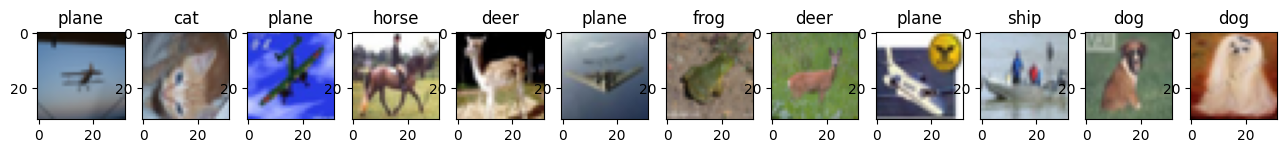

In [8]:
n_display = 12
random_ids = np.random.choice(len(x_train), n_display, replace=False)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_train_initial[random_ids[k]])
    axarr[k].title.set_text(classes[y_train[random_ids[k]][0]])

In [9]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print("Dimension des matrices d'étiquette de classe (train) :",y_train.shape)
print("Dimension des matrices d'étiquette de classe (val) :",y_val.shape)
print("Dimension des matrices d'étiquette de classe (test) :",y_test.shape)

Dimension des matrices d'étiquette de classe (train) : (5000, 10)
Dimension des matrices d'étiquette de classe (val) : (1000, 10)
Dimension des matrices d'étiquette de classe (test) : (1000, 10)


### II.2. Definition de l'architecture du CNN

Un simple réseau convolutionnel... 

In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.regularizers import l2
from keras import Input


def build_baseline_model():
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    model.add(
        Conv2D(
            filters=8,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            kernel_regularizer=l2(0.00),
        )
    )
    model.add(Dropout(0.0))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.00)))
    model.add(Dropout(0.0))
    model.add(Dense(10, activation='softmax', kernel_regularizer=l2(0.00)))
    model.add(Dropout(0.0))
    return model


model = build_baseline_model()


On enregistre les poids initiaux pour plus tard...

In [11]:
weights_init = model.get_weights()

### II.3. Definition de la fonction de coût et choix de l'algorithme d'optimisation

In [12]:
from keras.optimizers import Adam, SGD

opt = SGD(learning_rate=0.01, momentum=0.0)
# opt = Adam(learning_rate=0.001)
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


On affiche un résumé de la structure du modèle...

In [13]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,010 (515.66 KB)

 Trainable params: 132,010 (515.66 KB)

 Non-trainable params: 0 (0.00 B)

None


### II.4. Entraînement du CNN

*Definition du callback. A passer en première lecture.*

In [14]:
from keras.callbacks import Callback, ModelCheckpoint
import time


class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, batch, logs=None):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs=None):
        self.times.append(time.time() - self.epoch_time_start)


time_callback = TimeHistory()
filepath = 'my_model.h5'
checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
    save_freq='epoch',
)

callbacks = [time_callback, checkpoint]


In [15]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_val, y_val),
                    callbacks=callbacks)

Epoch 1/20



  1/157 ━━━━━━━━━━━━━━━━━━━━ 2:38 1s/step - accuracy: 0.0312 - loss: 2.7929


 13/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1152 - loss: 2.4676 


 26/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1285 - loss: 2.3996


 39/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1373 - loss: 2.3690

...


119/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8605 - loss: 0.4680


133/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8609 - loss: 0.4677


145/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8610 - loss: 0.4674


Epoch 20: val_accuracy did not improve from 0.44400



157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8644 - loss: 0.4621 - val_accuracy: 0.4070 - val_loss: 2.2252


### II.4.b. Campagne comparative de la Section 4 du rapport

La campagne comparative detaillee sur la taille du batch et sur les optimiseurs est desormais orchestr?e dans la Section V du notebook. Les details d'impl?mentation sont deplaces dans `scripts/section_4/` et `scripts/section_4/visualization/`, tandis que le notebook conserve les appels principaux, les resultats agreges et les observations associees.

Statistiques sur le temps d'entraînement d'une epoch

In [16]:
times = time_callback.times
print("Mean: {}".format(np.mean(times)))
print("Std: {}".format(np.std(times)))

Mean: 0.8941577911376953
Std: 0.30289584518878987


Tracé des courbes d'évolution des fonctions de coût

In [17]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

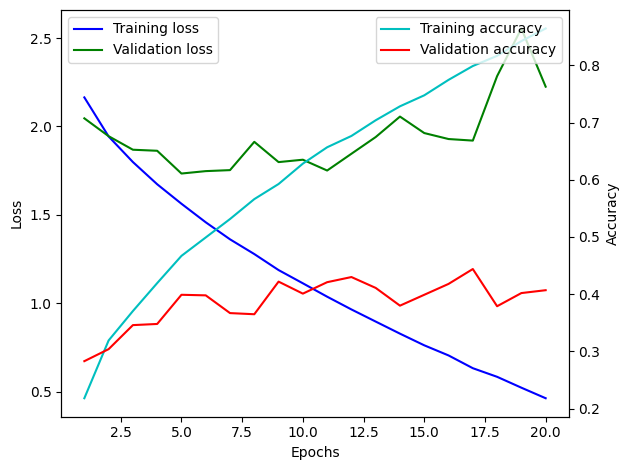

In [18]:
import matplotlib.pyplot as plt

history_dict = history.history
acc_key = 'accuracy' if 'accuracy' in history_dict else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history_dict else 'val_acc'
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict[acc_key]
val_acc_values = history_dict[val_acc_key]

epochs = range(1, len(history_dict[acc_key]) + 1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.plot(epochs, loss_values, color='b', label='Training loss')
ax1.plot(epochs, val_loss_values, color='g', label='Validation loss')
ax1.tick_params(axis='y')
plt.legend()

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy')
ax2.plot(epochs, acc_values, color='c', label='Training accuracy')
ax2.plot(epochs, val_acc_values, color='r', label='Validation accuracy')
ax2.tick_params(axis='y')

fig.tight_layout()
plt.legend(loc=1)
plt.show()


### II.5. Entraînement d'un CNN avec points d'arrêt et reprises (à passer en première lecture)

Pour des entraînements plus conséquents, il est primordial d'enregistrer les modèles intermédiaires afin de ne pas tout perdre si l'apprentissage venait à s'interrompre de façon impromptue. On peut enregistrer le modèle dans un fichier .hdf

Si vous regardez plus attentivement, lors de l'entrainement précédent nous avons crée un object **ModelCheckpoint**. Il permet d'enregistrer le meilleur modèle (au sens d'une metrique à préciser) dans un fichier nommé *my_model.h5*. Verifiez que ce fichier se trouve bien votre espace de travail.

L'argument ***period*** de l'objet ModelCheckpoint vous permet de definir la fréquence des enregistrements.

In [19]:
from keras.models import load_model

Une fois le modele obtenu, on peut l'enregister et le recharger comme ceci: load_model(filepath)

In [20]:
from keras.models import load_model
from keras.optimizers import SGD

import pathlib

file = pathlib.Path(filepath)
if file.exists():
    loaded_model = load_model(filepath, compile=False)
    model = build_baseline_model()
    model.set_weights(loaded_model.get_weights())
else:
    model = build_baseline_model()
    model.set_weights(weights_init)

opt_reload = SGD(learning_rate=0.01, momentum=0.0)
model.compile(
    optimizer=opt_reload,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

time_callback_2 = TimeHistory()
checkpoint_2 = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
    save_freq='epoch',
)
callbacks_2 = [time_callback_2, checkpoint_2]

history_2 = model.fit(
    x_train,
    y_train,
    batch_size=8,
    epochs=10,
    verbose=1,
    validation_data=(x_val, y_val),
    callbacks=callbacks_2,
)


Epoch 1/10



  1/625 ━━━━━━━━━━━━━━━━━━━━ 7:52 757ms/step - accuracy: 0.8750 - loss: 0.3227


 11/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8892 - loss: 0.4242    


 23/625 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8382 - loss: 0.5507


 36/625 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8145 - loss: 0.6039

...


585/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0187


601/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0187


619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0188


Epoch 10: val_accuracy did not improve from 0.44500



625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9988 - loss: 0.0205 - val_accuracy: 0.4420 - val_loss: 3.3602


# III - Test et Évaluation du modèle en prédiction

### III.1. Test du modèle sur les données de test

Testons la prédiction de notre modèle sur quelques images de test au hasard...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


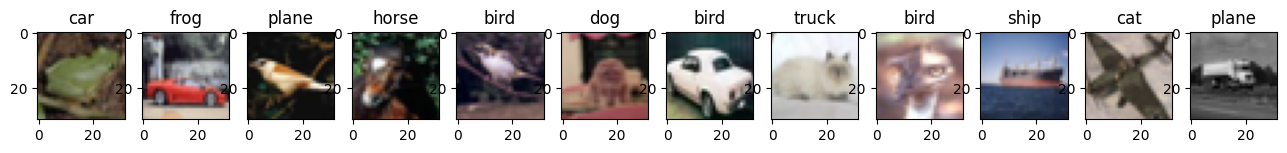

In [21]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
pred = np.argmax(model.predict(x_test[random_ids]), axis=1)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_test_initial[random_ids[k]])
    axarr[k].title.set_text(classes[pred[k]])

Vos premiers résultats semblent-ils corrects ?

Hum ! Affichons à présent la précision sur l'ensemble de votre base :

In [22]:
acc_key = 'accuracy' if 'accuracy' in history_dict else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history_dict else 'val_acc'
print("Pr?cision du r?seau sur les {} images d'entra?nement : {:.2f} %".format(n_training_samples, 100 * history_dict[acc_key][-1]))
print("Pr?cision du r?seau sur les {} images de validation : {:.2f} %".format(n_valid, 100 * history_dict[val_acc_key][-1]))


Pr?cision du r?seau sur les 5000 images d'entra?nement : 86.44 %
Pr?cision du r?seau sur les 1000 images de validation : 40.70 %


In [23]:
def accuracy_per_class(model):
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=np.int64)
    
    pred = np.argmax(model.predict(x_test), axis=1)
    for i in range(len(y_test)):
        confusion_matrix[np.argmax(y_test[i]), pred[i]] += 1
    
    print("{:<10} {:^10}".format("Classe", "Précision (%)"))
    total_correct = 0
    for i in range(n_classes):
        class_total = confusion_matrix[i, :].sum()
        class_correct = confusion_matrix[i, i]
        total_correct += class_correct
        percentage_correct = 100.0 * float(class_correct) / class_total
        print('{:<10} {:^10.2f}'.format(classes[i], percentage_correct))
    test_acc = 100.0 * float(total_correct) / len(y_test)
    print("Précision du réseau sur les {} images de test : {:.2f} %".format(len(y_test),test_acc))
    return confusion_matrix

confusion_matrix = accuracy_per_class(model)


 1/32 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step


28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Classe     Précision (%)
plane        47.37   
car          51.40   
bird         46.74   
cat          22.52   
deer         27.88   
dog          34.34   
frog         45.83   
horse        49.06   
ship         63.86   
truck        56.82   
Précision du réseau sur les 1000 images de test : 43.90 %


### III.2. Matrices de Confusion

Les matrices de confusion nous renseignent plus précisément sur la nature des erreurs commises par notre modèle.

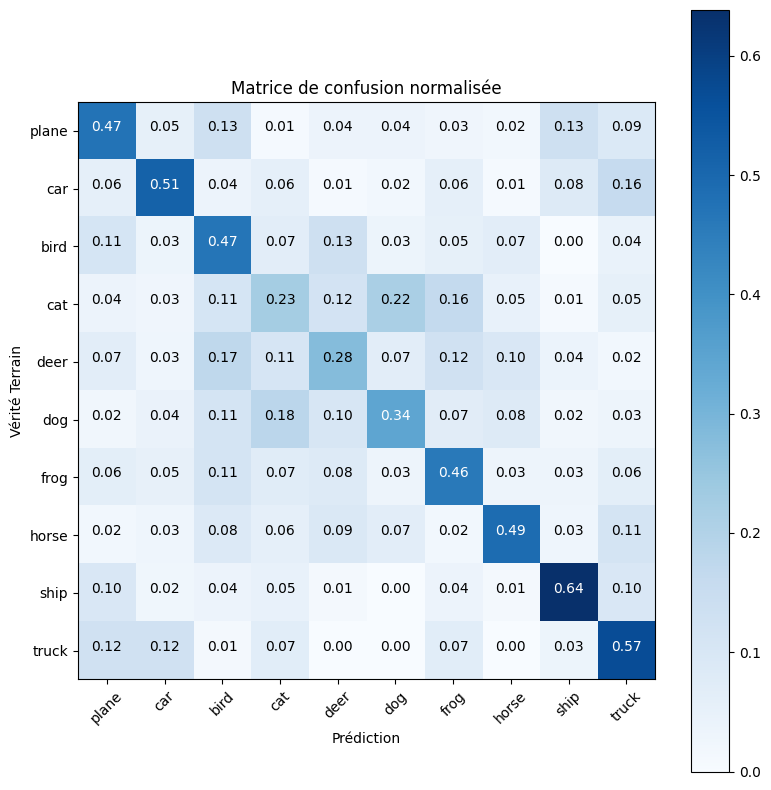

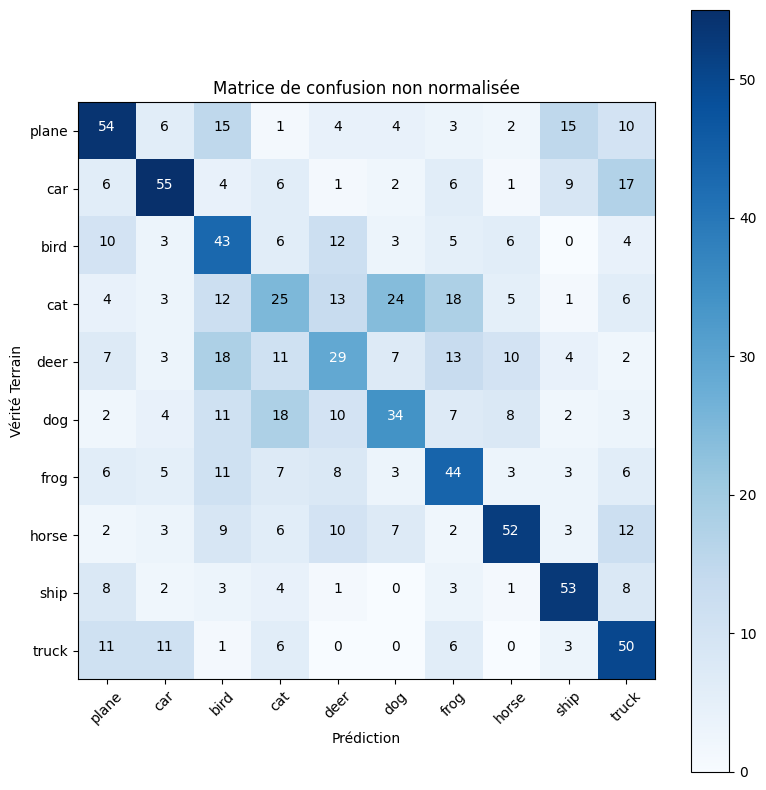

In [24]:
# Plot normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes, normalize=True,
                      title='Matrice de confusion normalisée')

# Plot non-normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes,
                      title='Matrice de confusion non normalisée')

# IV - Cartes d'activation pour la Section 8 du rapport

In [25]:
from IPython.display import Image, Markdown, display

from scripts.section_8 import (
    DEFAULT_RESULTS_PATH,
    get_section8_audit,
    get_section8_protocol,
    run_section8_pipeline,
)
from scripts.section_8.visualization import (
    DEFAULT_FIGURE_DIR,
    format_audit_markdown,
    format_protocol_markdown,
    format_section8_summary_markdown,
    load_image_paths,
    save_all_section8_figures,
)

In [26]:
section8_intro = {'meta': {'audit': get_section8_audit(), 'protocol': get_section8_protocol()}}

display(Markdown(format_audit_markdown(section8_intro)))
display(Markdown(format_protocol_markdown(section8_intro)))

results_path = DEFAULT_RESULTS_PATH
figure_dir = DEFAULT_FIGURE_DIR
force_recompute = False

print(f'Results cache: {results_path}')
print(f'Figure directory: {figure_dir}')

### IV.1. Diagnostic

- The original Part IV of the notebook only visualizes an aggregated first-layer mask from the baseline model.
- No usable deep-model checkpoints existed before Section 8, so a dedicated M3 reference run is needed to compare epochs 0, 1, 5 and 15.
- The best Section 6 / Section 7 model family can be reused directly through M3, which keeps Section 8 coherent with the rest of the TP.

| Parameter | Value |
| --- | --- |
| Reference model | M3 / R3 three-stage CNN with dropout and L2 |
| Reference seed | 42 |
| Reference epochs | 15 |
| Selected layers | conv_s1_1, conv_s2_2, conv_s3_2 |
| Evolution layers | conv_s1_1, conv_s3_2 |
| Selected epochs | 0, 1, 5, 15 |
| Primary class | truck |
| Secondary class | frog |
| Static normalization | Per-map min-max scaling to [0,1] |
| Evolution normalization | Fixed per-channel scaling across the selected epochs |

Results cache: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section8\section8_results.json
Figure directory: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs


In [27]:
section8_results = run_section8_pipeline(
    output_path=results_path,
    force_recompute=force_recompute,
    verbose=True,
)
section8_figures = save_all_section8_figures(section8_results, figure_dir=figure_dir)
section8_results['meta']['results_path'] = str(results_path)
section8_results['meta']['figure_paths'] = {name: str(path) for name, path in section8_figures.items()}

print(f"Primary image: {section8_results['selected_images']['primary']['true_class_name']}"
      f" (index {section8_results['selected_images']['primary']['index']}, "
      f"confidence {section8_results['selected_images']['primary']['confidence']:.4f})")
print(f"Secondary image: {section8_results['selected_images']['secondary']['true_class_name']}"
      f" (index {section8_results['selected_images']['secondary']['index']}, "
      f"confidence {section8_results['selected_images']['secondary']['confidence']:.4f})")
for name, path in section8_figures.items():
    print(f'{name}: {path}')

Primary image: truck (index 626, confidence 0.9933)
Secondary image: frog (index 100, confidence 0.9962)
first_layer: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section8_first_layer_activation_maps.png
deep_layers: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section8_deep_layer_activation_maps.png
evolution: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section8_activation_evolution.png


### IV.3. Images et observations retenues

- Image principale : index `626`, classe `truck`, confiance `0.9933`.
- Image secondaire : index `100`, classe `frog`, confiance `0.9962`.
- Canaux de premiere couche les plus lies au gradient : `[1, 14, 12]`.
- Canaux de premiere couche les plus lies au contraste chromatique : `[10, 7, 8]`.

| Analysis | Layers | Epochs | Displayed channels | Observation |
| --- | --- | --- | --- | --- |
| First-layer maps | conv_s1_1 | 15 | 16 | Mean positive ratio 0.464; normalized entropy 0.847; maps remain spatially dense and locally interpretable. |
| Deep-layer maps | conv_s2_2, conv_s3_2 | 15 | 8 + 8 | Mean positive ratio decreases from 0.422 to 0.402; entropy decreases from 0.780 to 0.679. |
| Evolution during training | conv_s1_1, conv_s3_2 | 0, 1, 5, 15 | 2 + 2 | Activation std increases by 0.031 in conv_s1_1 and by 0.303 in conv_s3_2. |

### IV.4. Cartes de la premiere couche

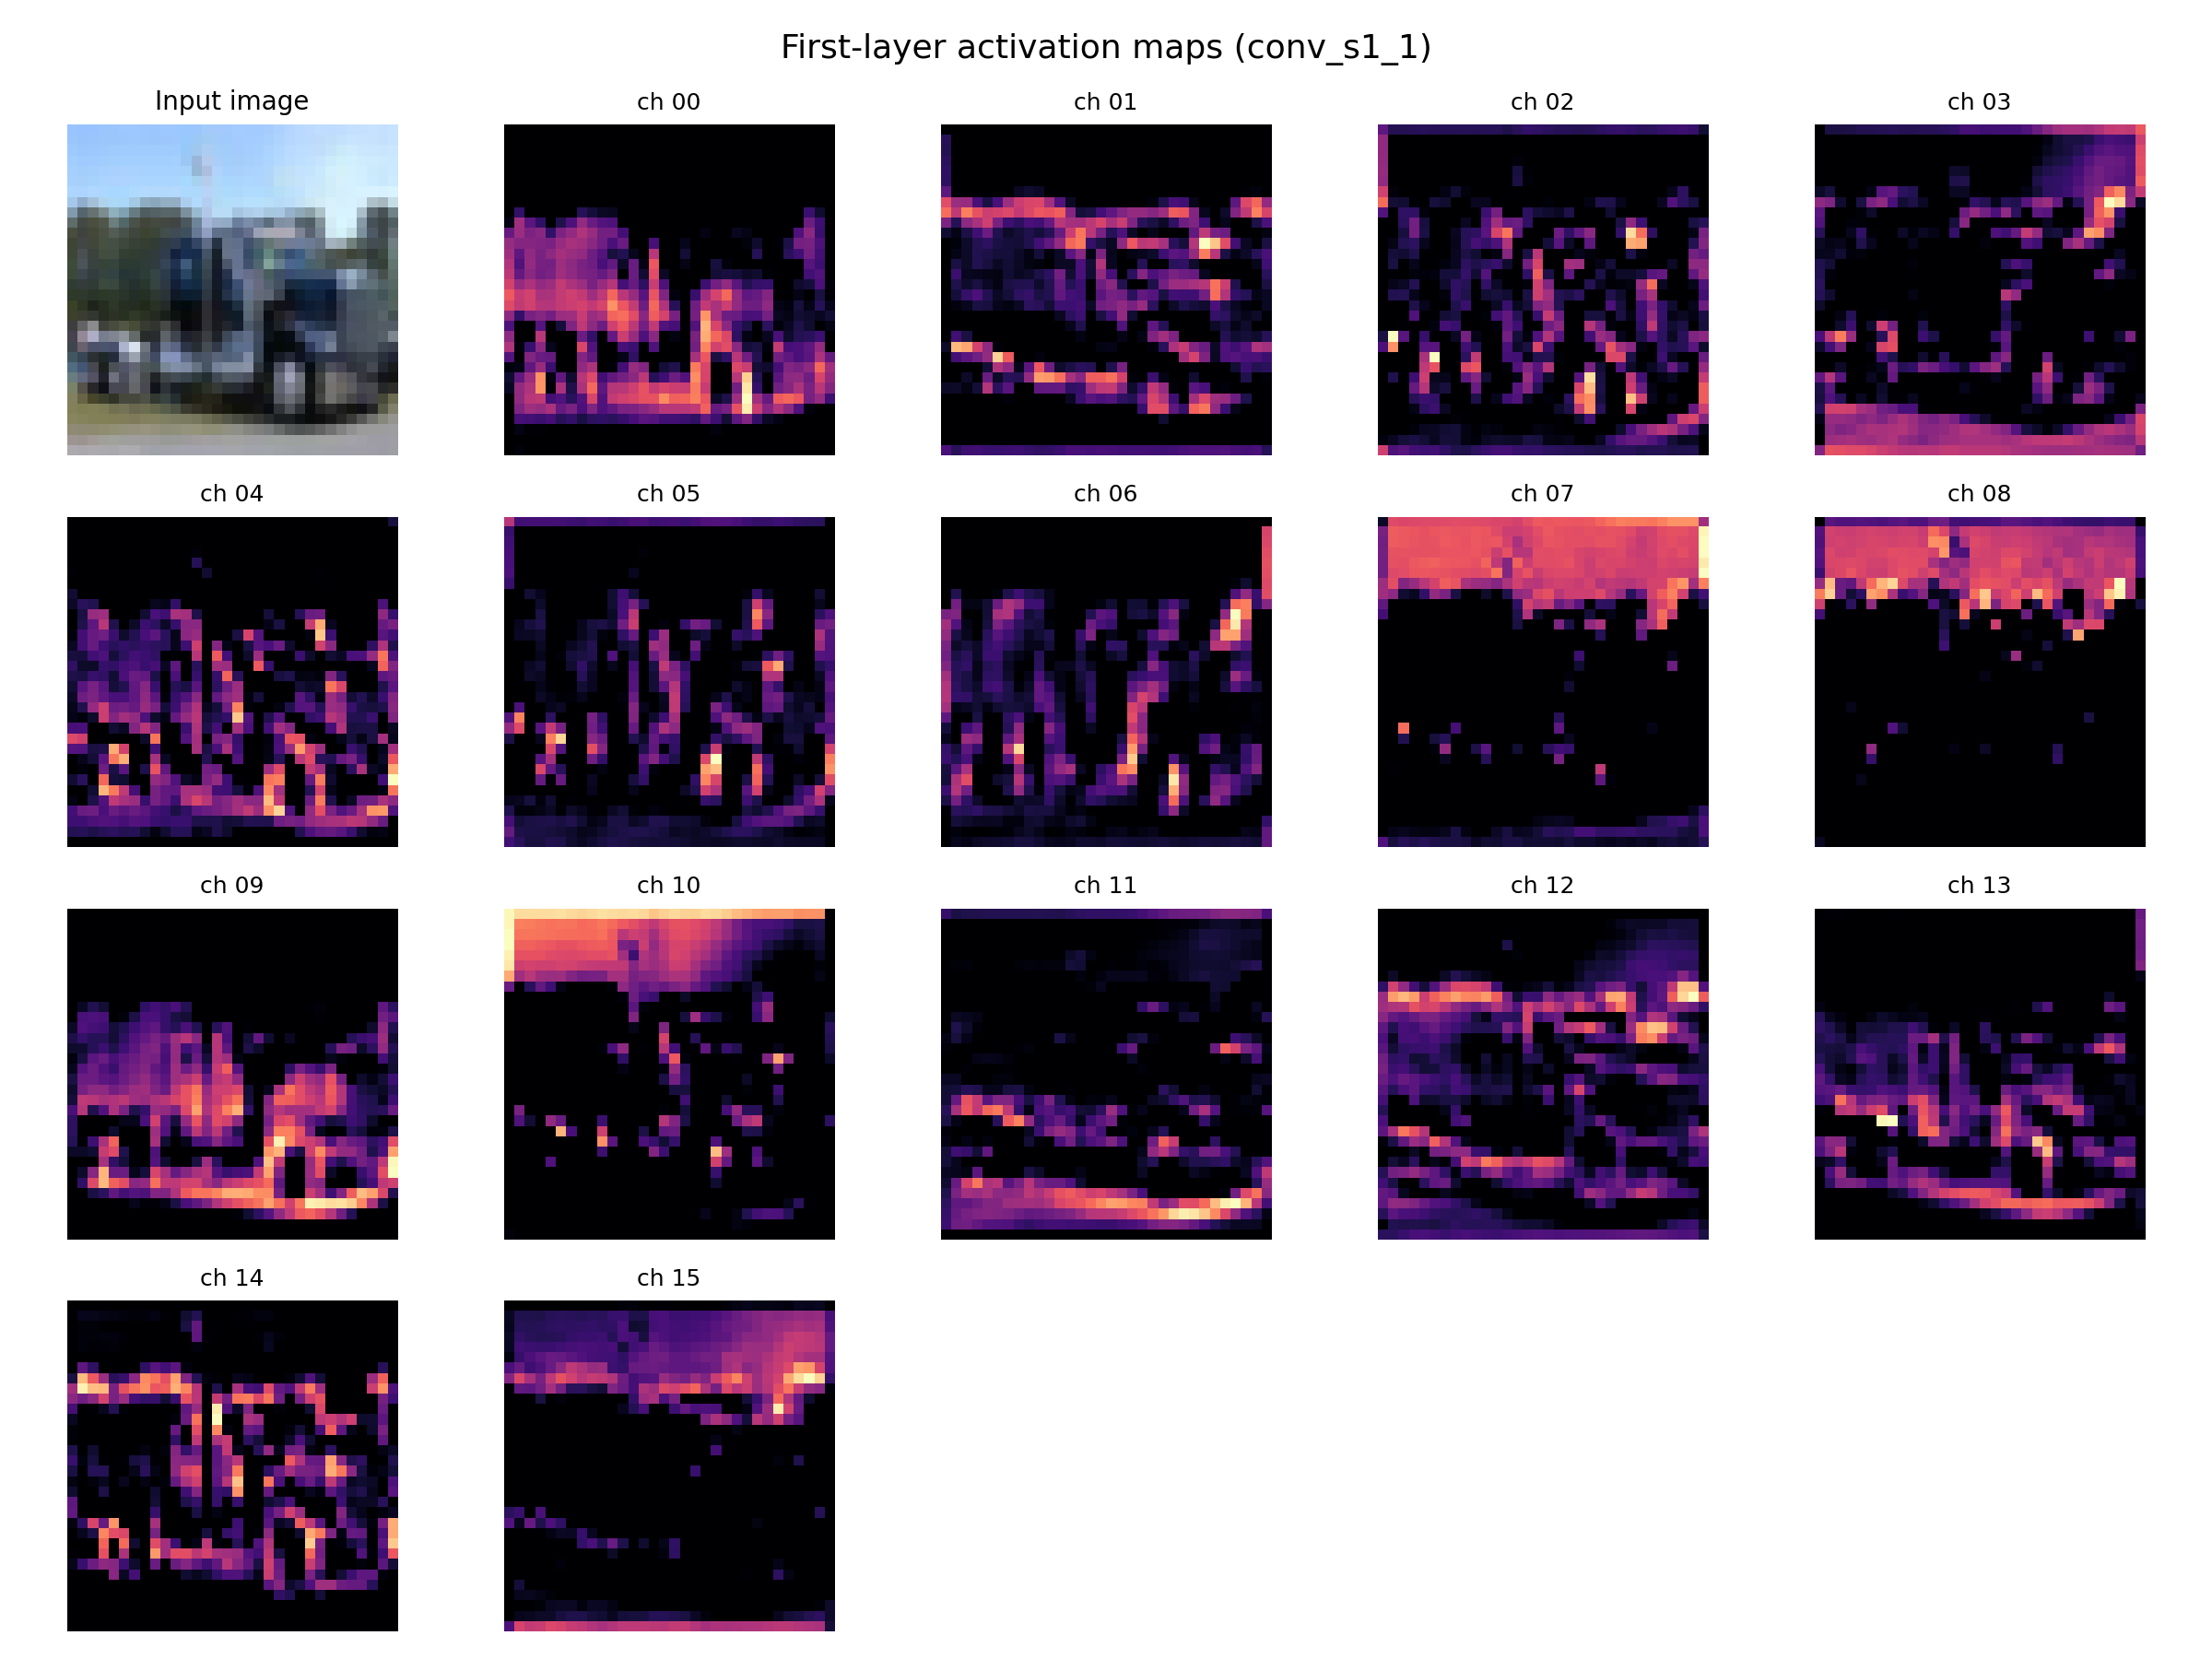

### IV.5. Cartes des couches profondes

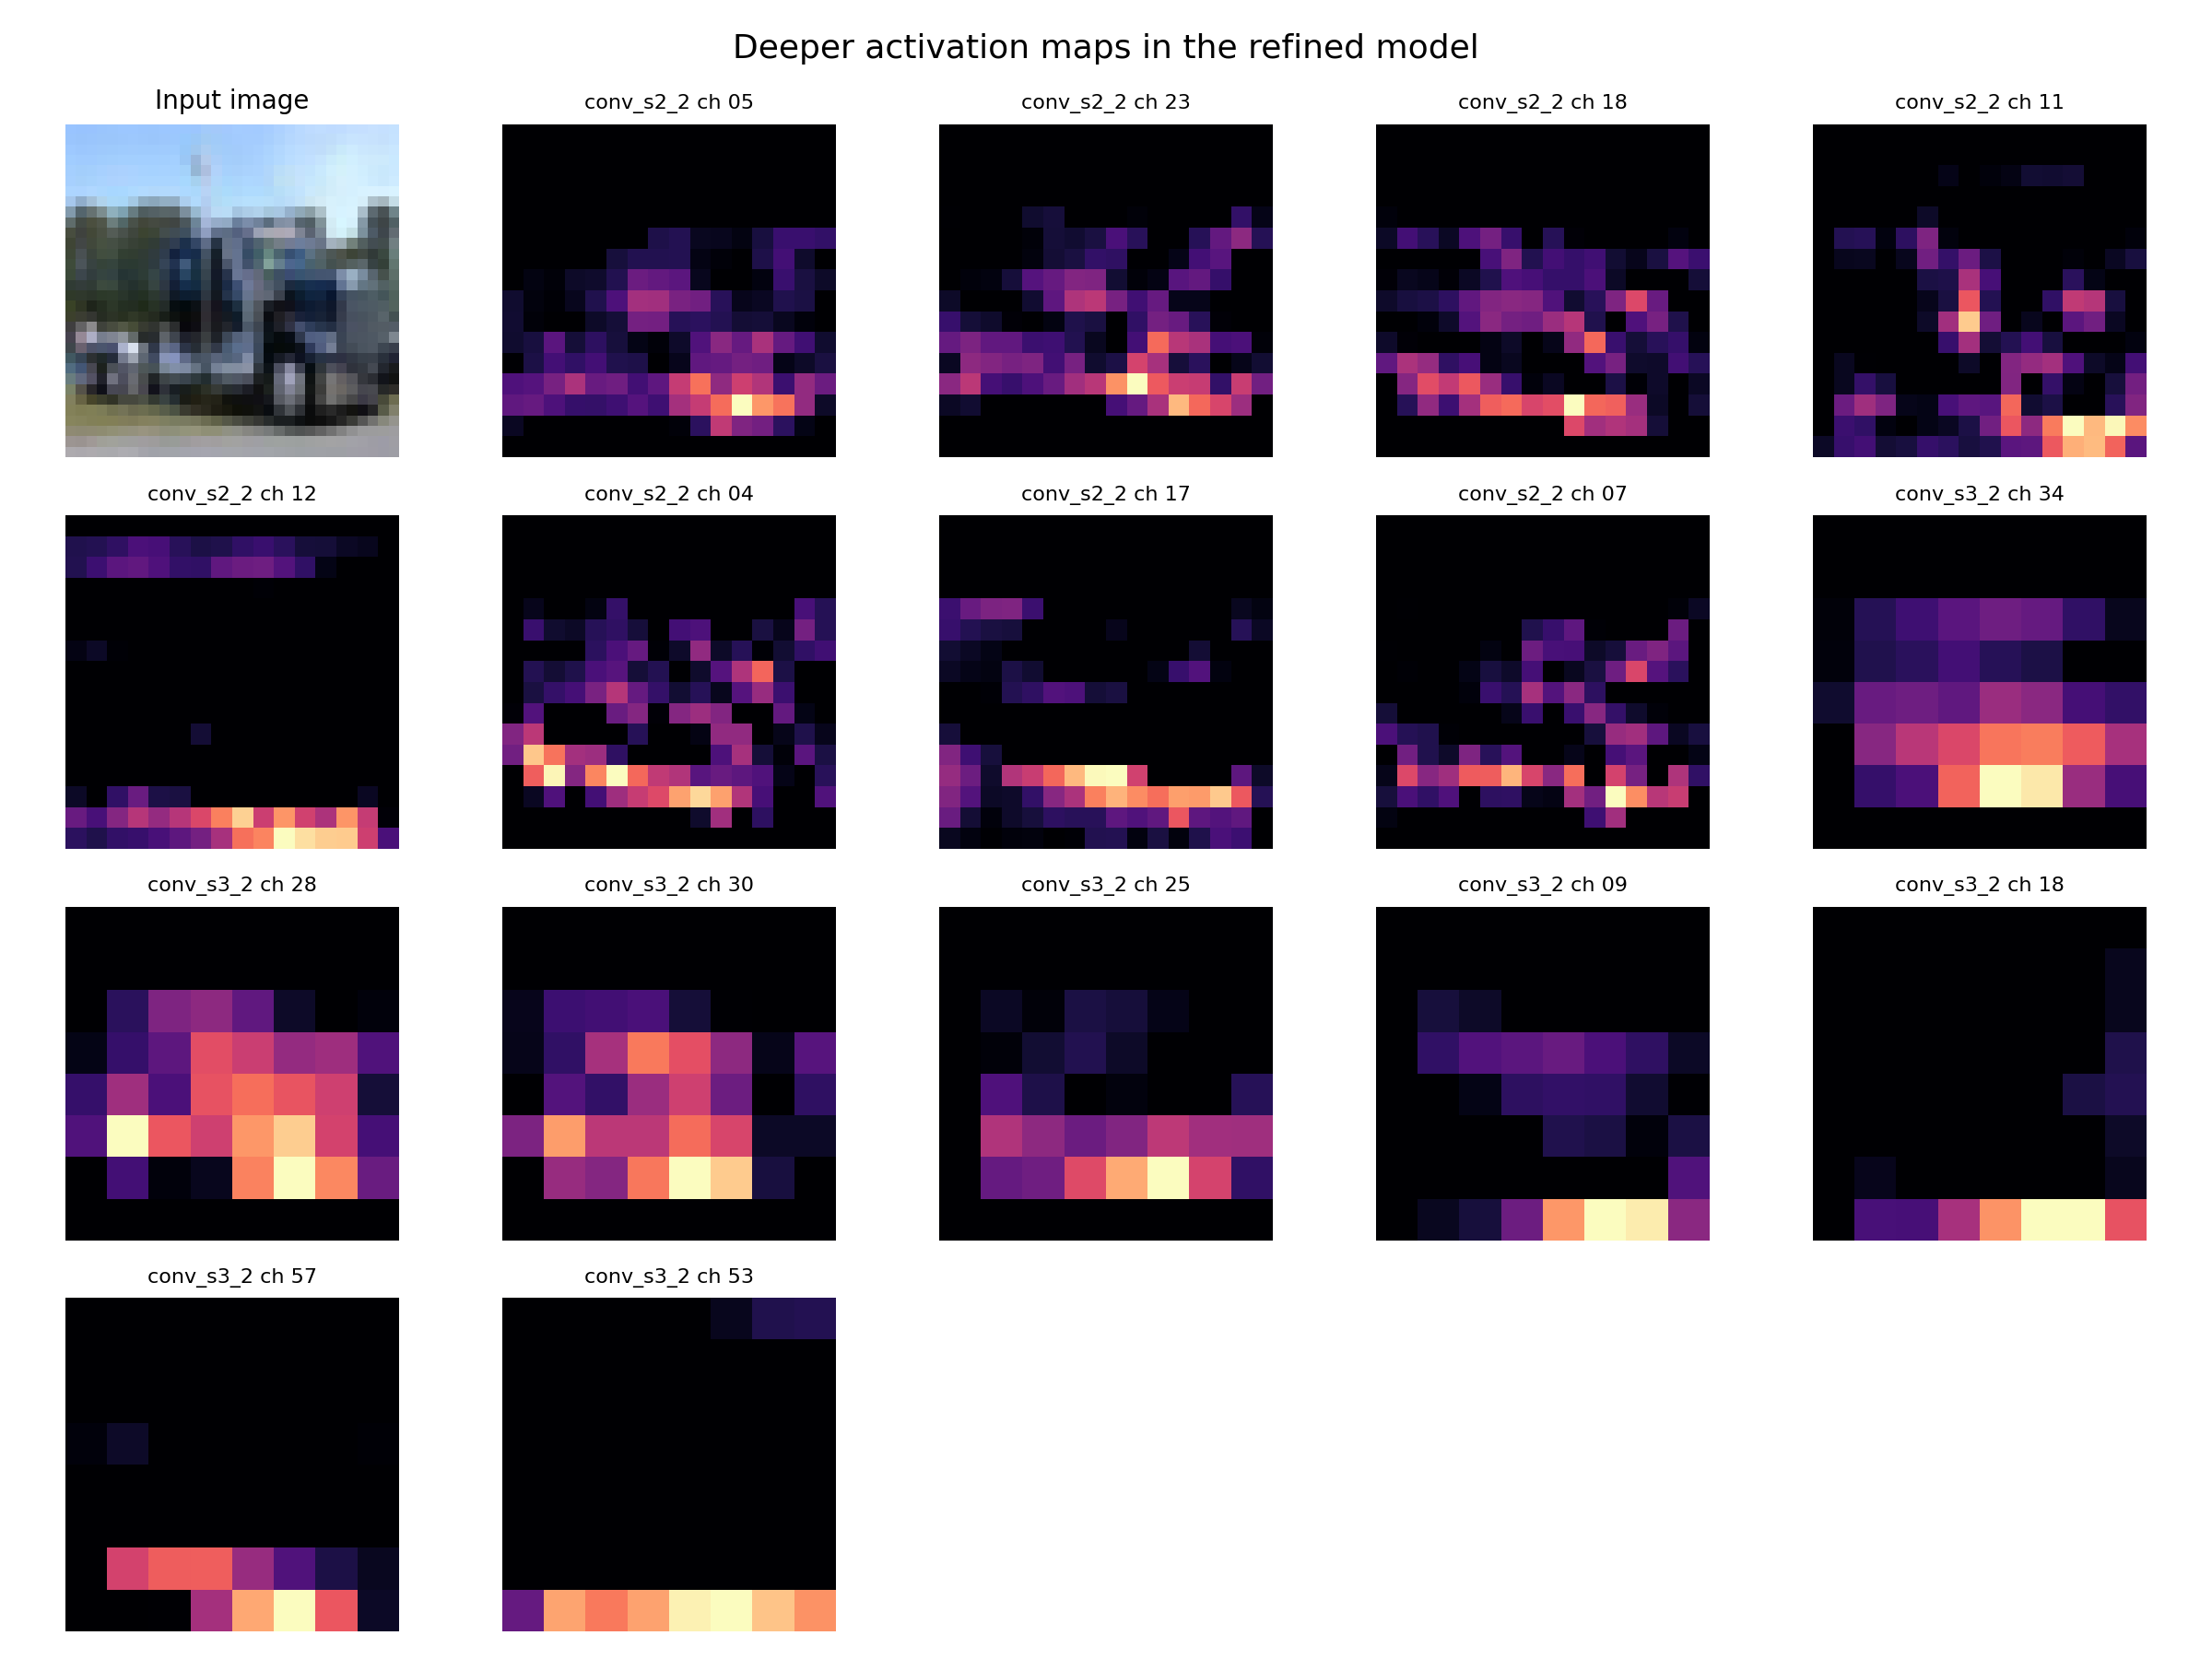

### IV.6. Evolution des cartes pendant l apprentissage

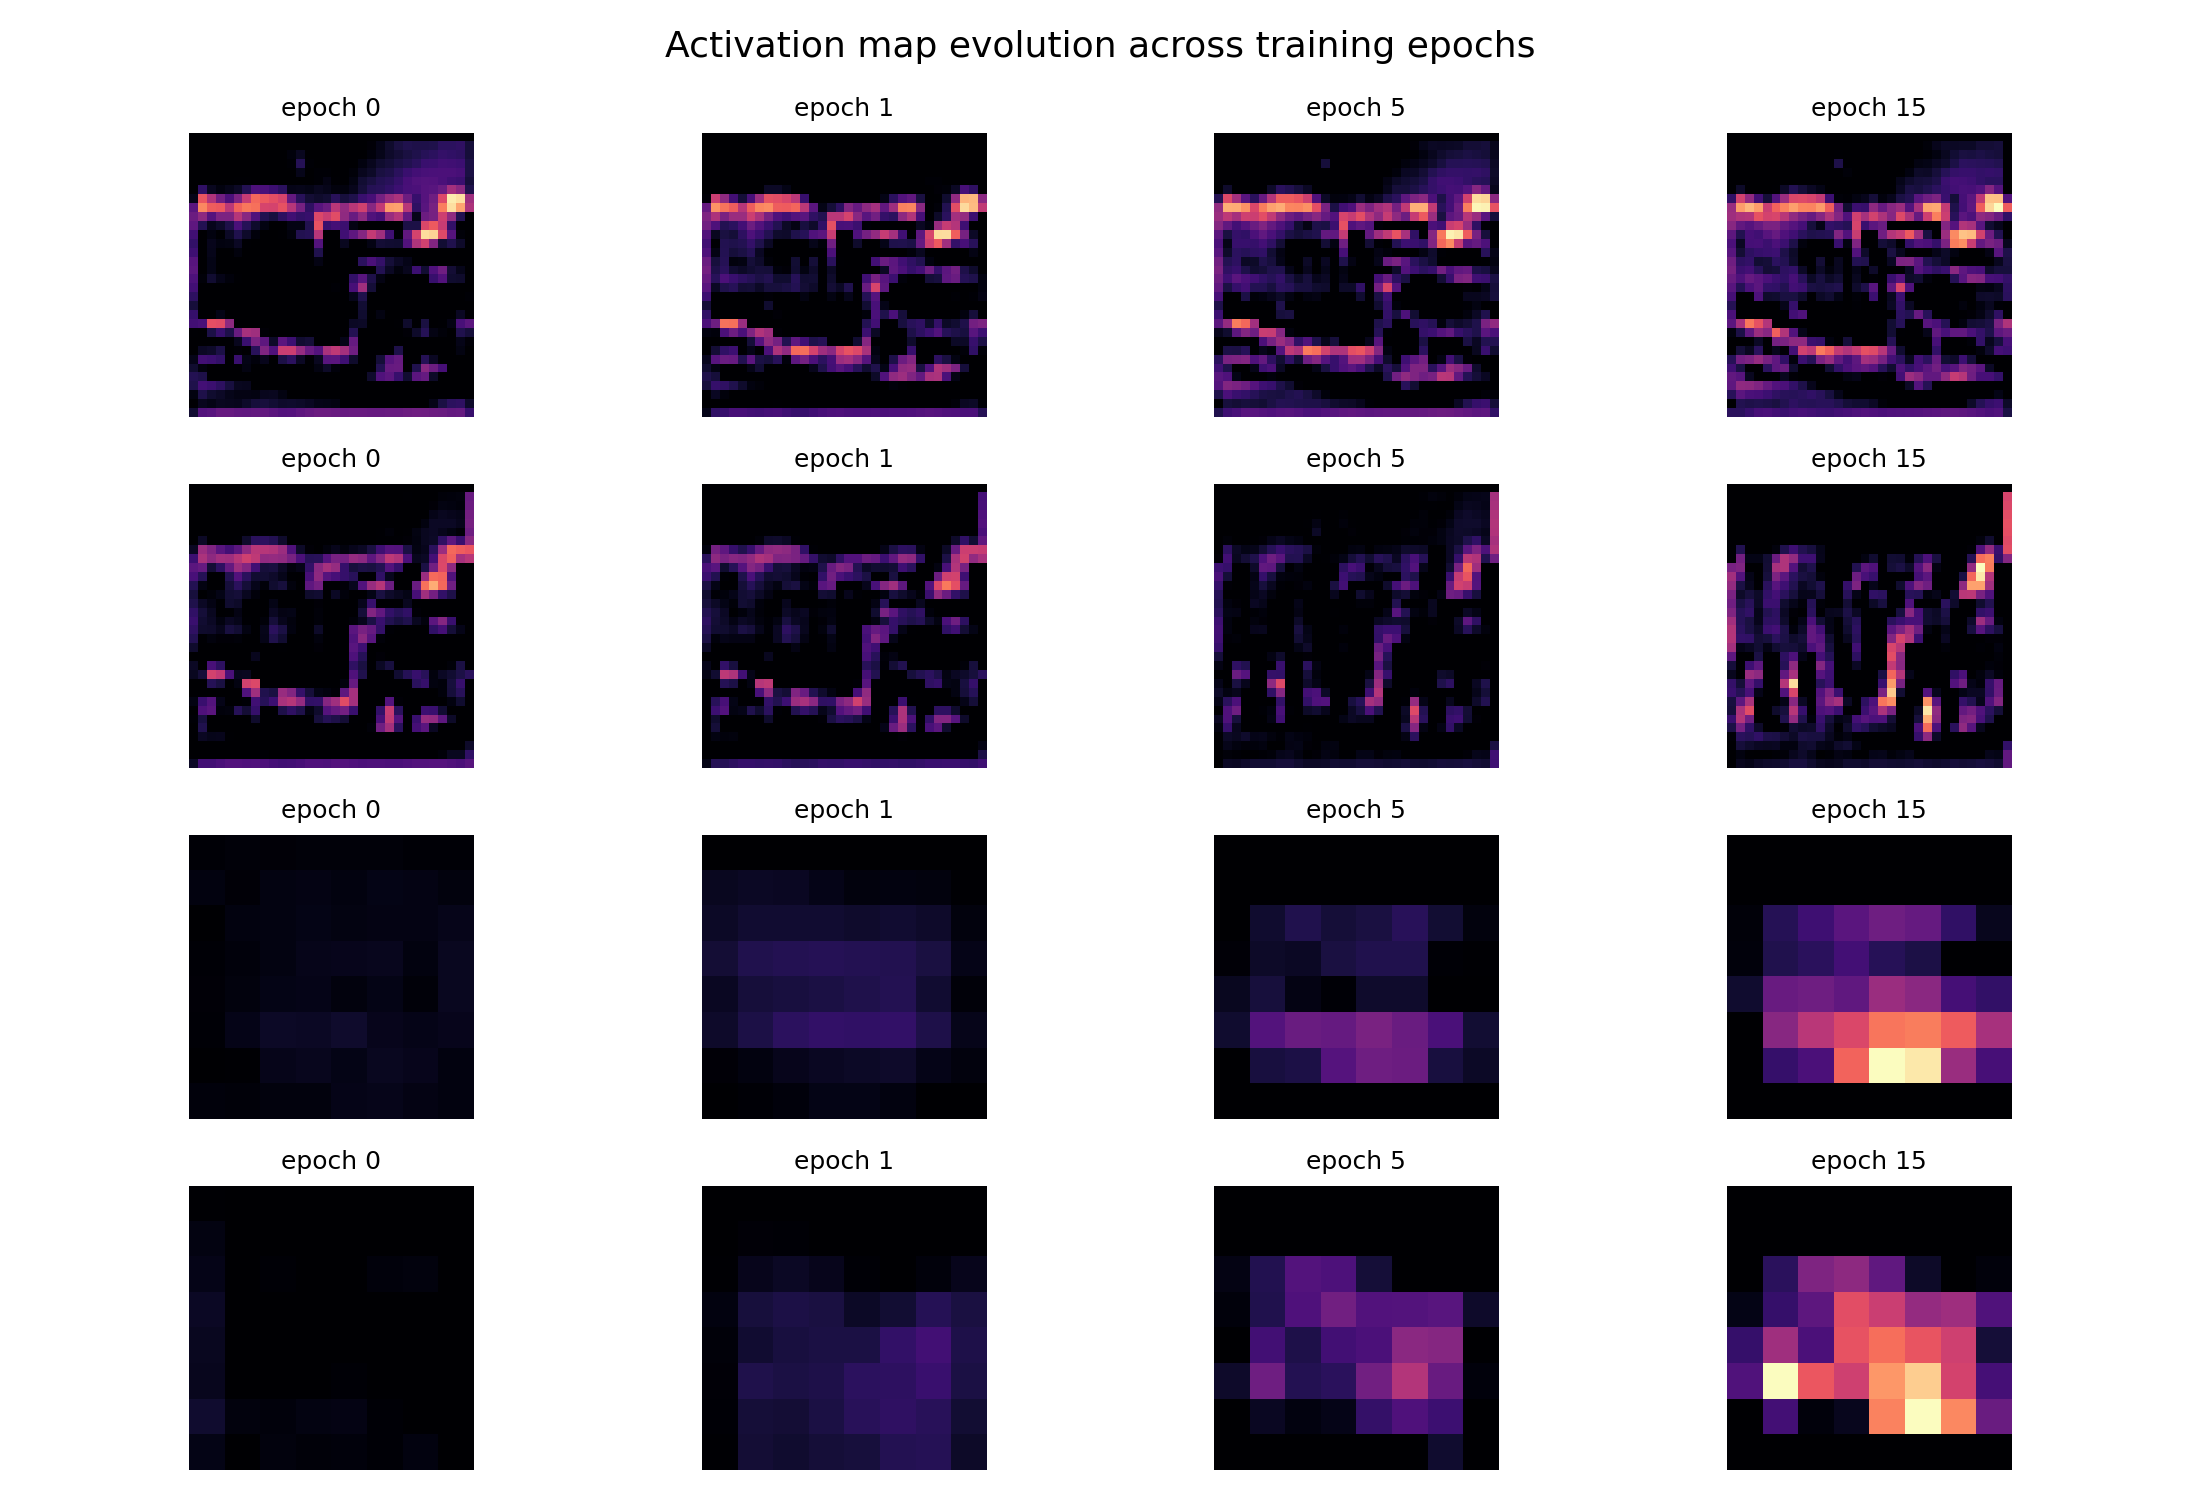

In [28]:
display(Markdown(format_section8_summary_markdown(section8_results)))

section8_image_paths = load_image_paths(figure_dir)
section8_titles = {
    'first_layer': '### IV.4. Cartes de la premiere couche',
    'deep_layers': '### IV.5. Cartes des couches profondes',
    'evolution': '### IV.6. Evolution des cartes pendant l apprentissage',
}

for key in ('first_layer', 'deep_layers', 'evolution'):
    display(Markdown(section8_titles[key]))
    display(Image(filename=str(section8_image_paths[key])))

# V - Campagne expérimentale pour la Section 4 du rapport

Cette section orchestre les expériences utilisées dans la rédaction de la Section 4 du rapport. Le notebook expose le protocole, appelle les fonctions utilitaires stockées dans `scripts/section_4/`, recharge les résultats agrégés et affiche les figures retenues pour l'analyse.


In [29]:
from IPython.display import Image, Markdown, display

from scripts.section_4 import (
    BATCH_SIZES,
    BATCH_STUDY_EPOCHS,
    DEFAULT_RESULTS_PATH,
    OPTIMIZER_BATCH_SIZE,
    OPTIMIZER_CONFIGS,
    OPTIMIZER_STUDY_EPOCHS,
    TRAINING_SEEDS,
    get_section4_protocol,
    run_section4_pipeline,
)
from scripts.section_4.visualization import (
    DEFAULT_FIGURE_DIR,
    format_batch_summary_markdown,
    format_optimizer_summary_markdown,
    format_protocol_markdown,
    load_image_paths,
    save_all_section4_figures,
)


In [30]:
section4_protocol = get_section4_protocol()
display(Markdown("### V.1. Protocole retenu"))
display(Markdown(format_protocol_markdown(section4_protocol)))

print("Batch sizes testés :", BATCH_SIZES)
print("Optimiseurs comparés :", [config["name"] for config in OPTIMIZER_CONFIGS])
print("Graines d'entraînement :", TRAINING_SEEDS)
print("Nombre d'epochs (batch size) :", BATCH_STUDY_EPOCHS)
print("Nombre d'epochs (optimiseurs) :", OPTIMIZER_STUDY_EPOCHS)
print("Batch size fixe pour la comparaison d'optimiseurs :", OPTIMIZER_BATCH_SIZE)

results_path = DEFAULT_RESULTS_PATH
figure_dir = DEFAULT_FIGURE_DIR
force_recompute = False  # True recomputes the full campaign from the notebook.


### V.1. Protocole retenu

| Parametre | Valeur |
| --- | --- |
| Sections de reference | Section II pour les donnees et la standardisation, Section III pour l'architecture |
| Sous-ensembles | 5000 train / 1000 validation / 1000 test |
| Graine de partition | 42 |
| Graines d'entrainement | 42, 314 |
| Comparaison batch size | 8 epochs fixes, batch sizes 8, 16, 32, 64, 128 |
| Comparaison optimiseurs | 8 epochs fixes, batch size 32 |
| SGD | lr=0.01, momentum=0.0 |
| SGD+Momentum | lr=0.01, momentum=0.9 |
| Adam | lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07 |
| Convention de loss | sum_over_batch_size |
| Temps/step | mean over the recorded training-batch wall times |
| Temps/epoch | per-epoch wall time including validation |

Batch sizes testés : [8, 16, 32, 64, 128]
Optimiseurs comparés : ['SGD', 'SGD+Momentum', 'Adam']
Graines d'entraînement : [42, 314]
Nombre d'epochs (batch size) : 8
Nombre d'epochs (optimiseurs) : 8
Batch size fixe pour la comparaison d'optimiseurs : 32


In [31]:
section4_results = run_section4_pipeline(
    output_path=results_path,
    force_recompute=force_recompute,
    verbose=True,
)
section4_figures = save_all_section4_figures(section4_results, figure_dir=figure_dir)

print(f"Résultats agrégés : {results_path}")
for name, figure_path in section4_figures.items():
    print(f"{name}: {figure_path}")


Loading existing Section 4 results from Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section4\section4_results.json


Résultats agrégés : Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section4\section4_results.json
batch_step_time: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_batch_step_time.png
batch_epoch_time: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_batch_epoch_time.png
batch_curves: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_batch_curves.png
optimizer_curves: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_optimizer_curves.png
optimizer_summary: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_optimizer_summary.png


In [32]:
display(Markdown("### V.2. Synthèse agrégée : taille du batch"))
display(Markdown(format_batch_summary_markdown(section4_results)))

display(Markdown("### V.3. Synthèse agrégée : optimiseurs"))
display(Markdown(format_optimizer_summary_markdown(section4_results)))


### V.2. Synthèse agrégée : taille du batch

| Batch size | Steps/epoch | Temps/step (s) | Temps/epoch (s) | Accuracy finale val. (%) | Min. val. loss |
| --- | --- | --- | --- | --- | --- |
| 8 | 625 | 0.0050 +/- 0.0098 | 3.692 +/- 0.463 | 42.55 | 1.6833 |
| 16 | 313 | 0.0072 +/- 0.0123 | 2.695 +/- 0.442 | 41.80 | 1.7038 |
| 32 | 157 | 0.0111 +/- 0.0162 | 2.102 +/- 0.375 | 38.60 | 1.7584 |
| 64 | 79 | 0.0183 +/- 0.0225 | 1.766 +/- 0.311 | 35.35 | 1.8489 |
| 128 | 40 | 0.0355 +/- 0.0453 | 1.735 +/- 0.441 | 30.65 | 1.9489 |

### V.3. Synthèse agrégée : optimiseurs

| Optimiseur | Temps/epoch (s) | Accuracy finale val. (%) | Min. val. loss |
| --- | --- | --- | --- |
| SGD | 2.278 +/- 0.330 | 38.60 | 1.7584 |
| SGD+Momentum | 2.164 +/- 0.408 | 40.20 | 1.7079 |
| Adam | 2.151 +/- 0.522 | 43.45 | 1.6083 |

### V.4. Figures utilisées dans la Section 4

**Temps moyen par step selon la taille du batch**

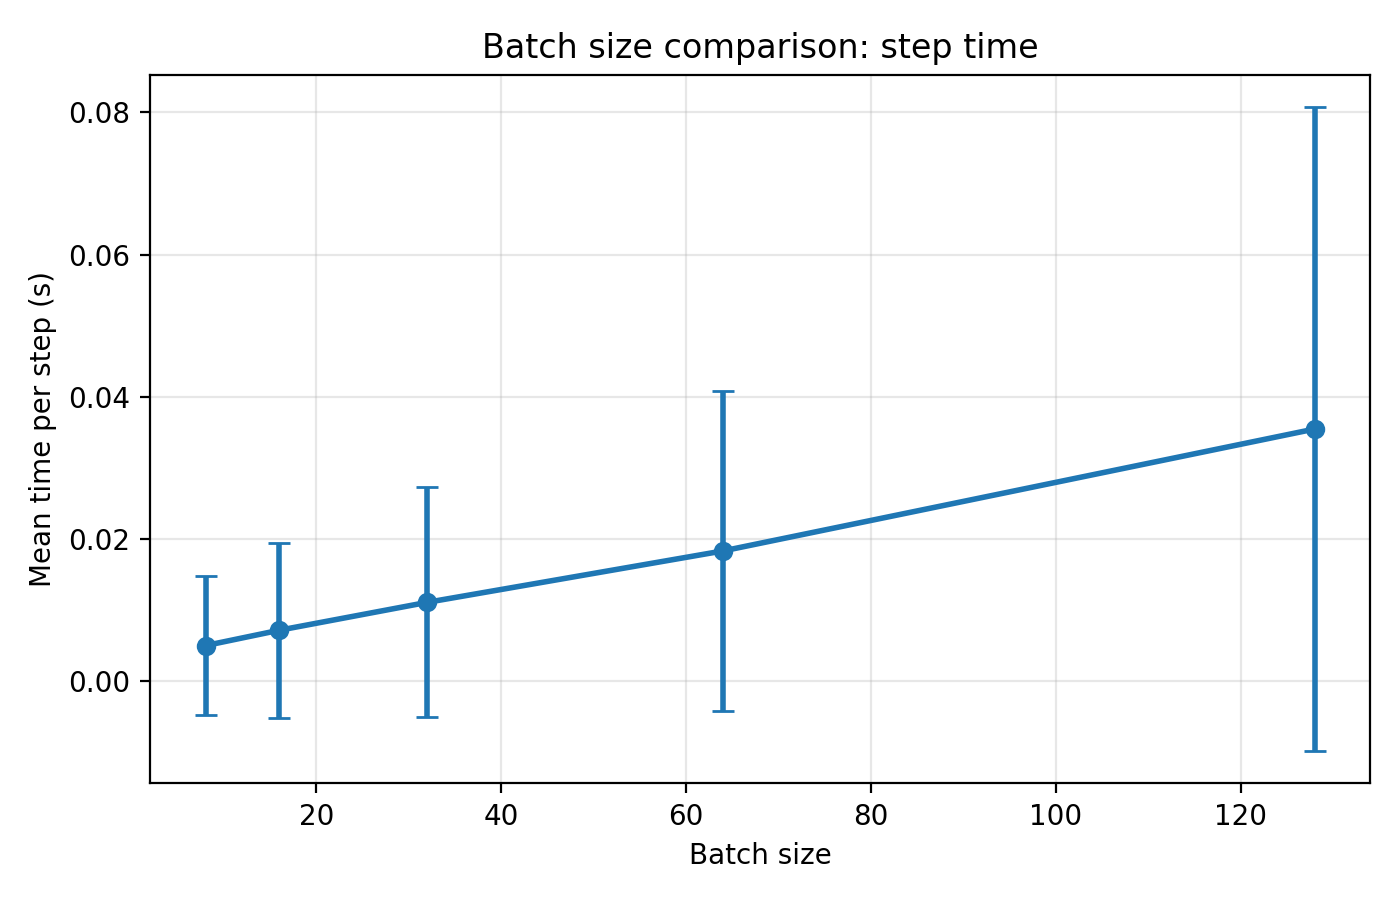

**Temps moyen par epoch selon la taille du batch**

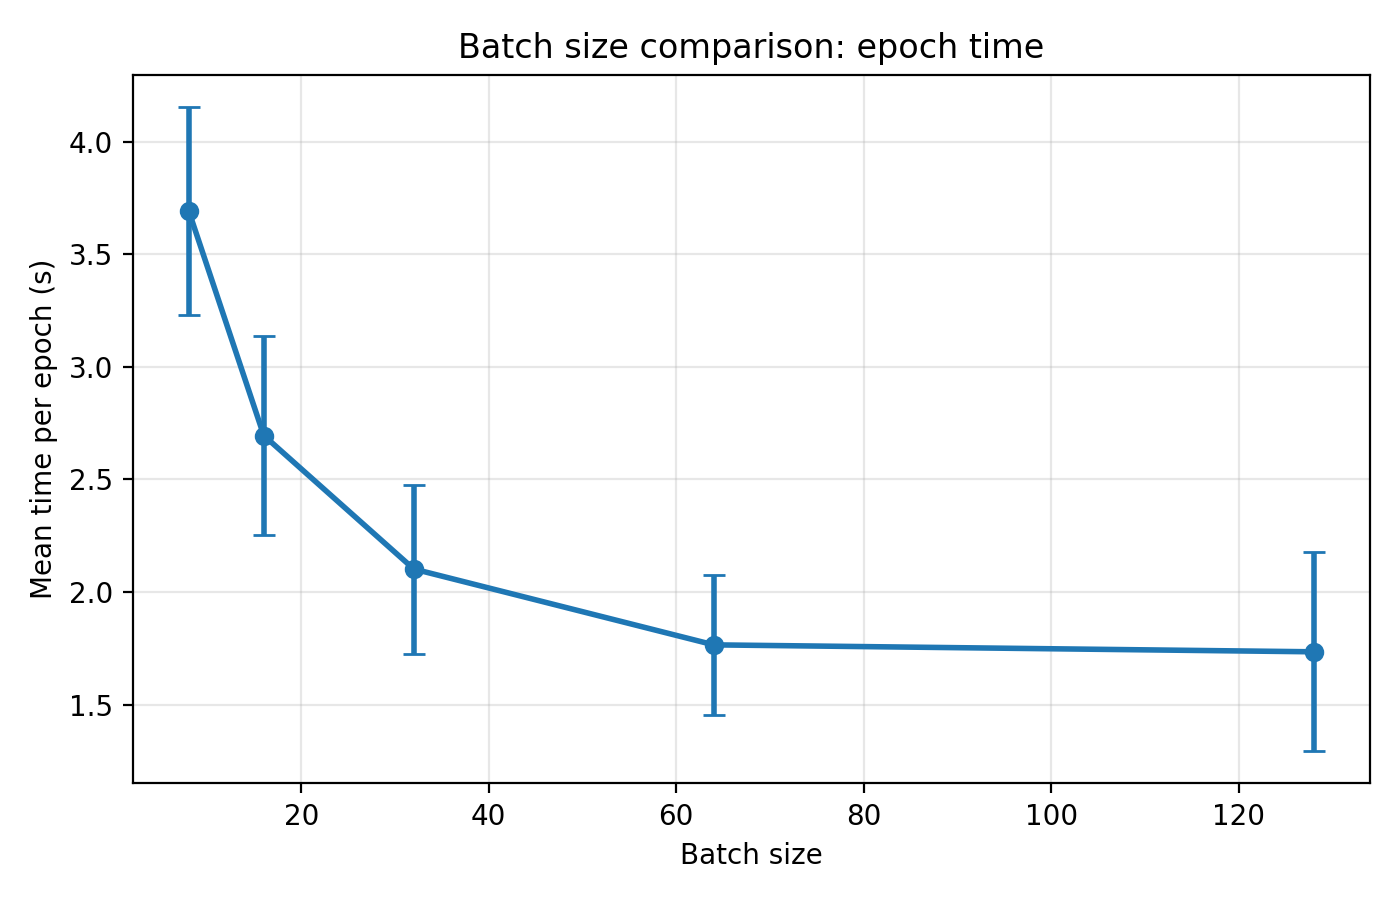

**Courbes d'apprentissage pour les batch sizes testés**

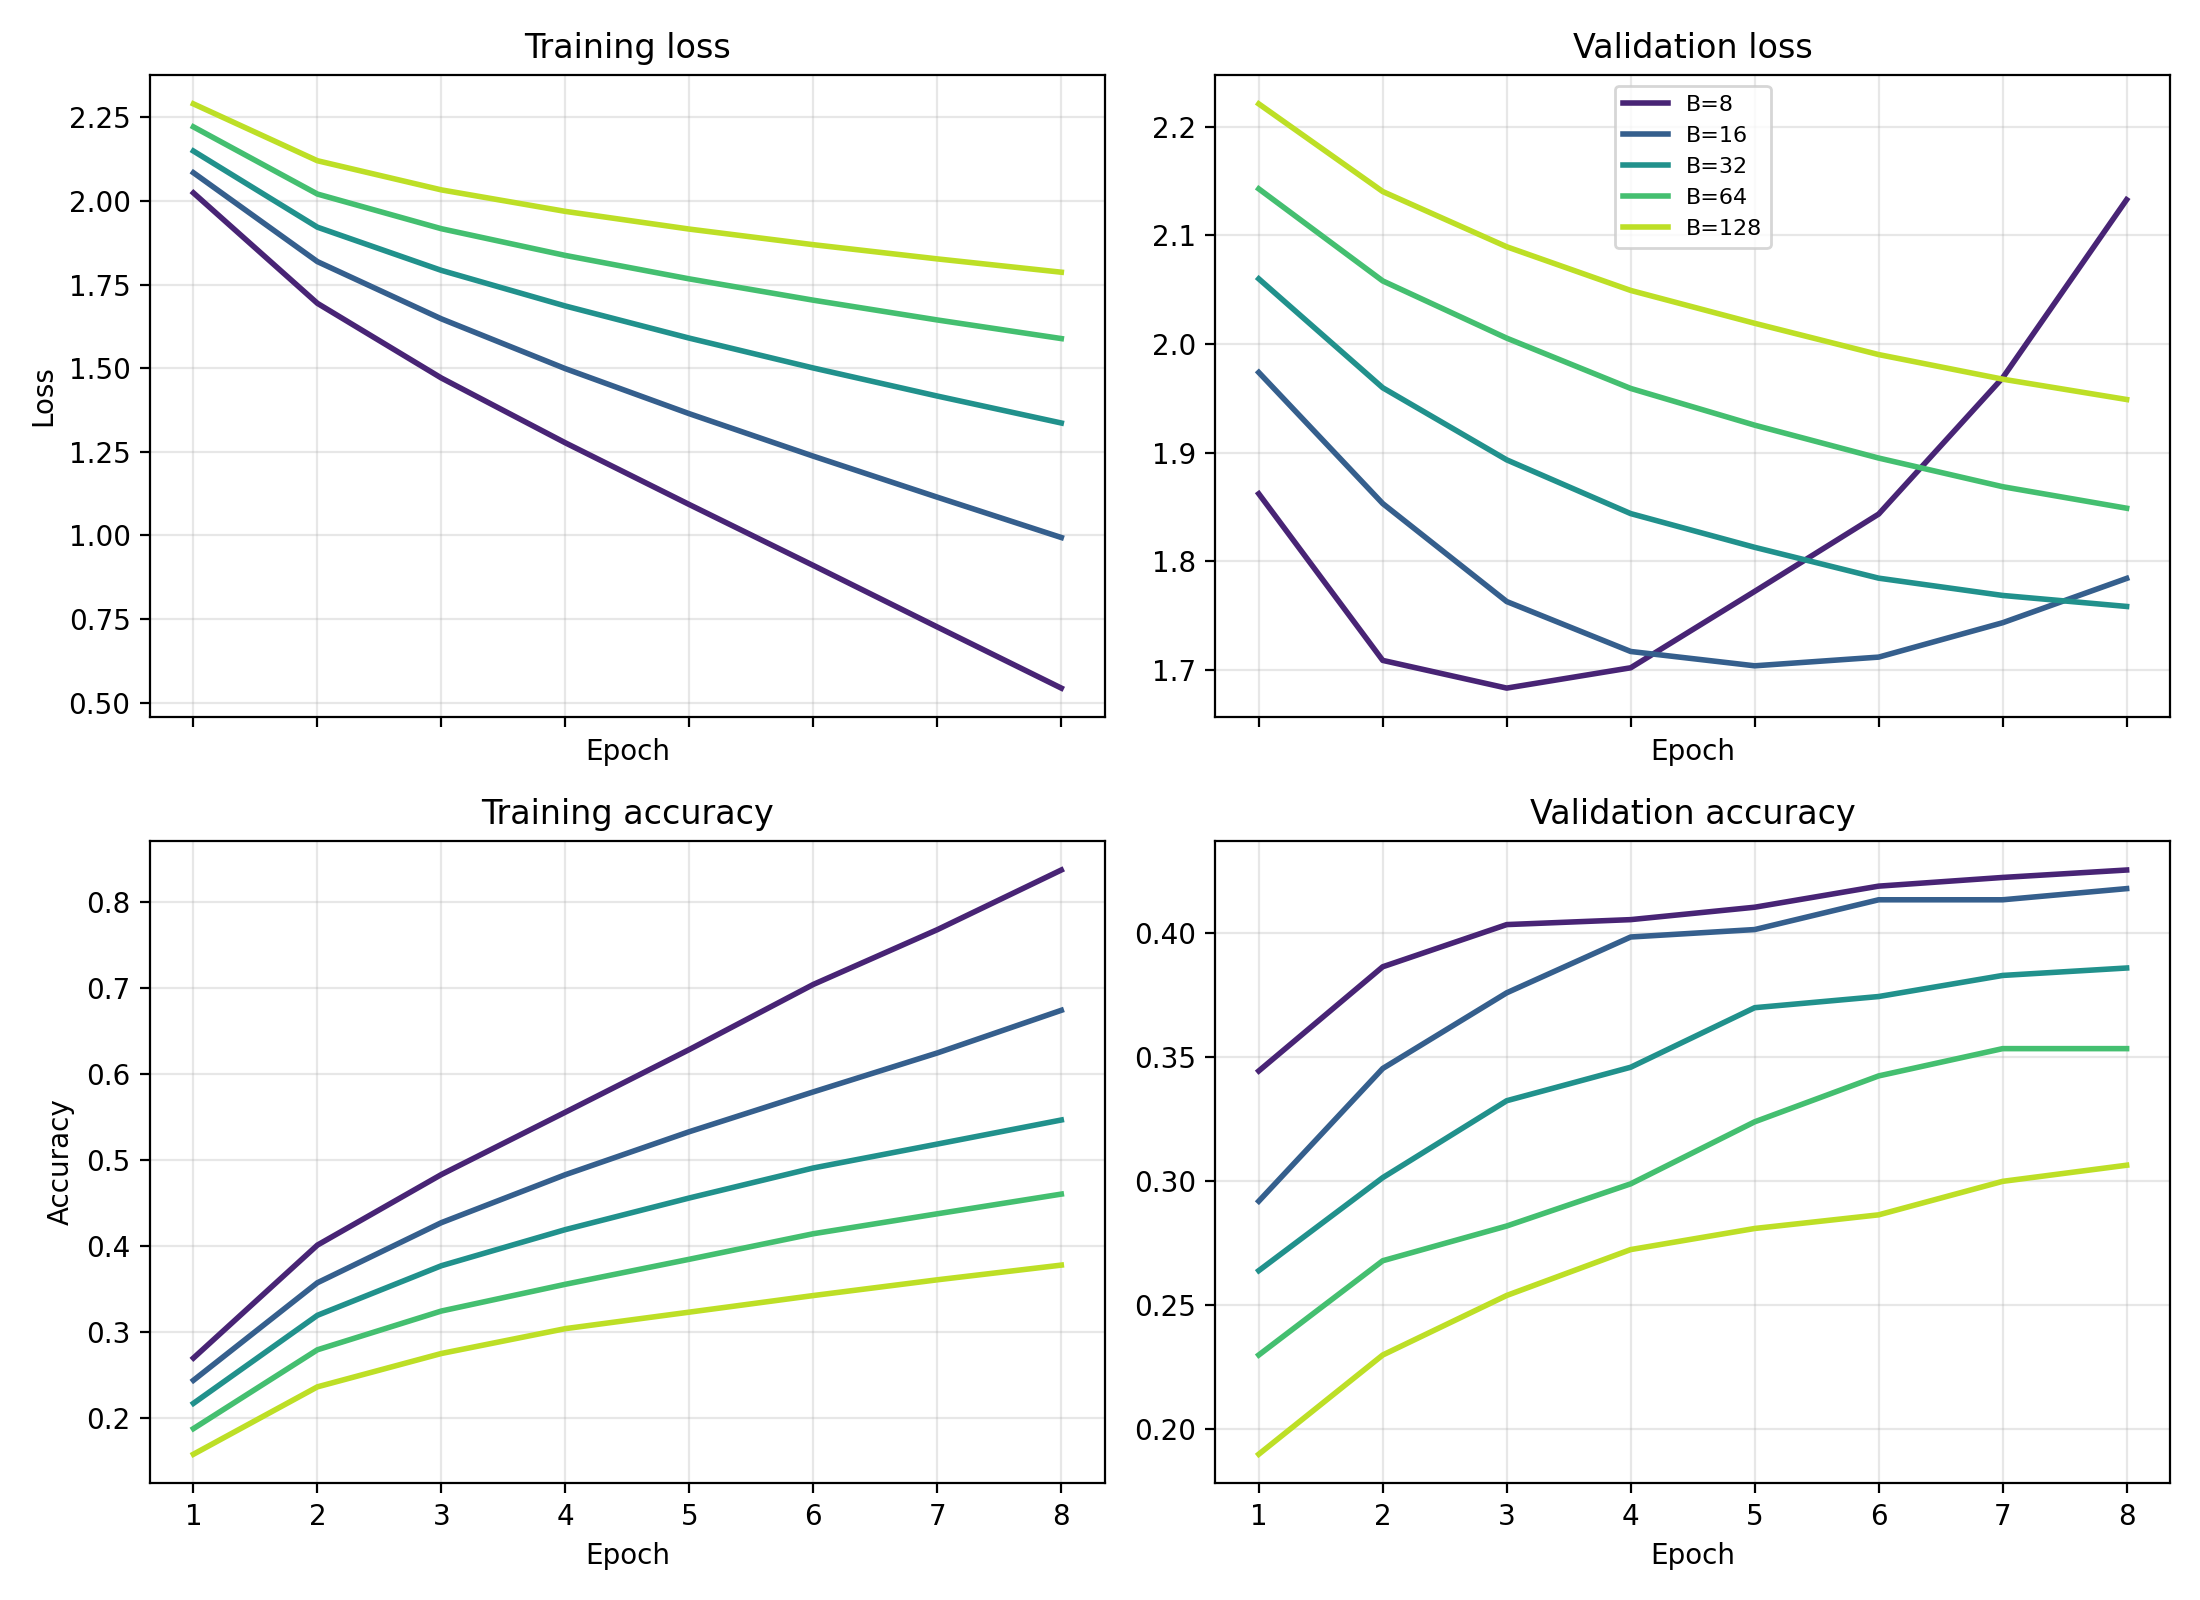

**Courbes d'apprentissage pour les optimiseurs comparés**

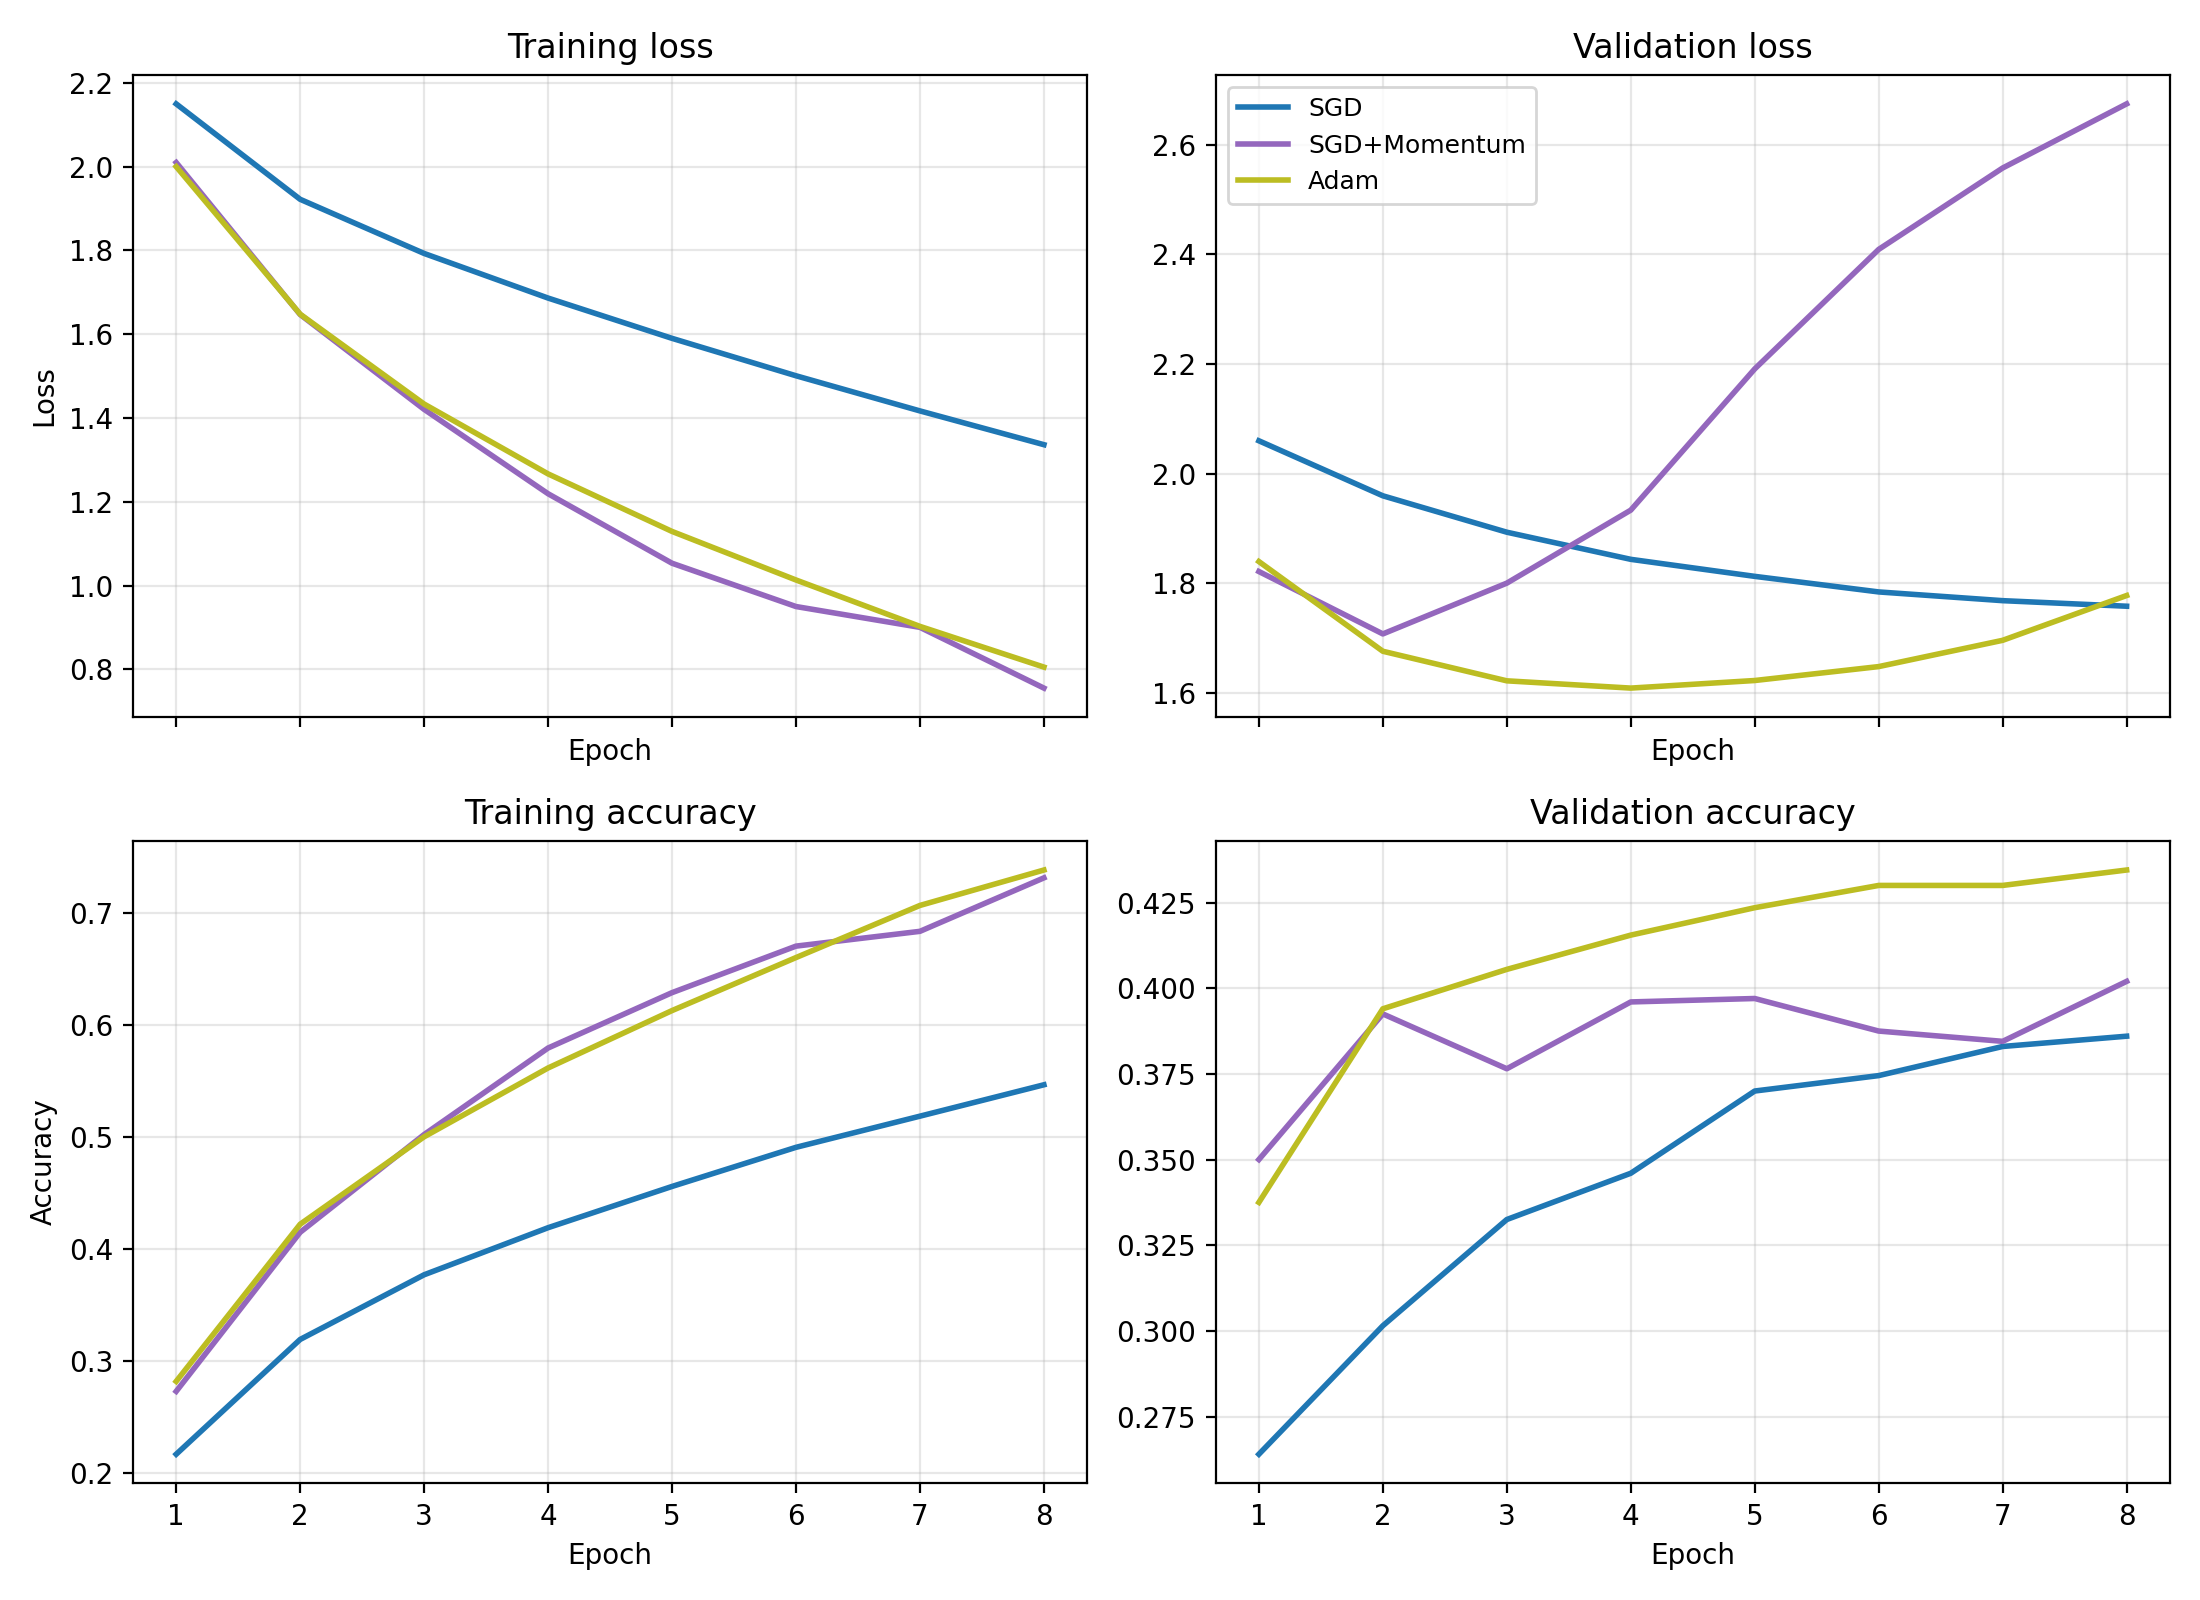

**Synthèse visuelle de la comparaison des optimiseurs**

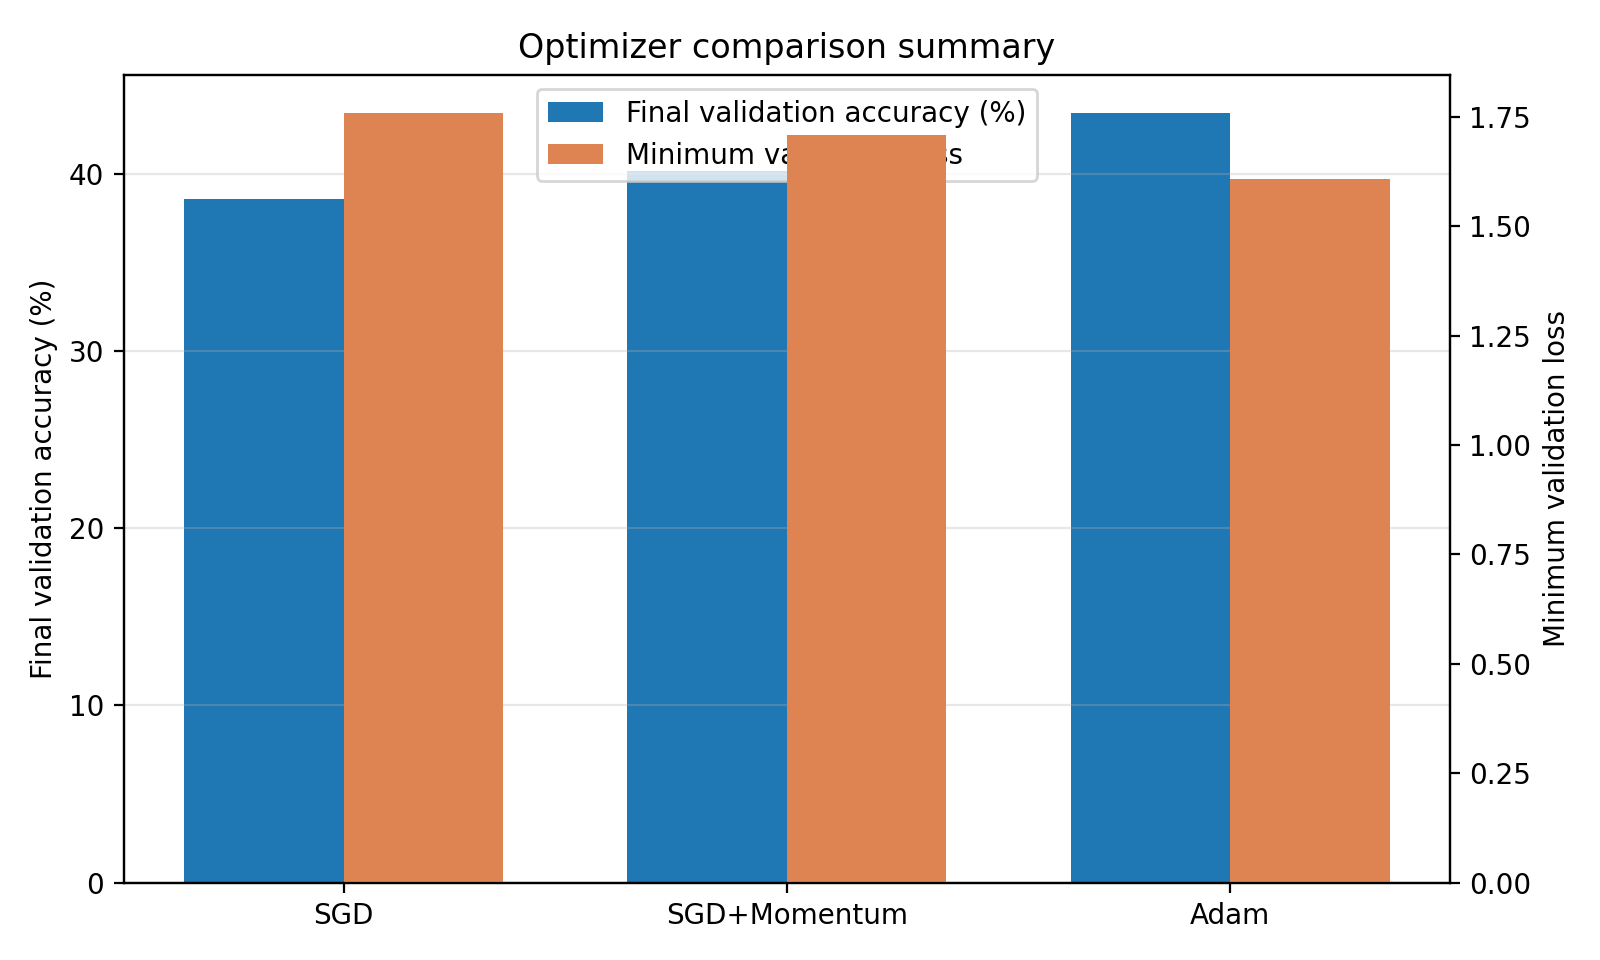

In [33]:
display(Markdown("### V.4. Figures utilisées dans la Section 4"))
image_paths = load_image_paths(figure_dir)
for key, title in [ 
    ("batch_step_time", "Temps moyen par step selon la taille du batch"),
    ("batch_epoch_time", "Temps moyen par epoch selon la taille du batch"),
    ("batch_curves", "Courbes d'apprentissage pour les batch sizes testés"),
    ("optimizer_curves", "Courbes d'apprentissage pour les optimiseurs comparés"),
    ("optimizer_summary", "Synthèse visuelle de la comparaison des optimiseurs"),
]:
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(image_paths[key])))


### V.5. Observations principales

- À budget fixe en epochs, les batch sizes les plus petits fournissent les meilleures performances de validation, tandis que les batch sizes les plus grands réduisent surtout le temps moyen par epoch.
- Le batch size $16$ fournit le compromis le plus équilibré entre stabilité, coût calculatoire et précision finale sur le protocole CPU retenu.
- Adam domine la comparaison d'optimiseurs sur cette campagne, avec la meilleure accuracy finale de validation et la plus faible val. loss minimale.
- Le SGD avec Momentum accélère la descente initiale, mais sa courbe de validation devient moins stable que celle d'Adam sur la fin de l'entraînement.


# VI - Inventaire des hyperparamètres pour la Section 5 du rapport

Cette section du notebook sert de point d'entrée pour la Section 5 du rapport. La logique d'inventaire détaillée est placée dans `scripts/section_5/`, mais le notebook conserve ici le diagnostic, la distinction entre paramètres appris et hyperparamètres, la classification par nature et les observations finales.


In [34]:
from IPython.display import Markdown, display

from scripts.section_5 import (
    format_audit_markdown,
    format_classification_summary_markdown,
    format_inventory_markdown,
    format_non_hyperparameter_markdown,
    format_section5_conclusion_markdown,
    format_trainable_parameter_markdown,
    get_section5_payload,
)


In [35]:
section5_payload = get_section5_payload()

display(Markdown(format_audit_markdown()))
display(Markdown(format_trainable_parameter_markdown(section5_payload['trainable_summary'])))

### VI.1. Diagnostic

- L'inventaire doit distinguer les hyperparametres un par un, et non seulement par familles.
- Les quantites imposees par la tache, les hyperparametres ajustables et les conditions experimentales doivent etre separees plus strictement.
- Les hyperparametres d'optimisation deja etudies en Section 4 doivent etre rappeles ici sans dupliquer l'analyse experimentale complete.
- Le notebook et le helper peuvent fournir un inventaire analytique code par code, ancre explicitement dans les appels Keras utilises.

### VI.2. Distinction entre parametres appris et hyperparametres

Le modele contient **132010 parametres trainables**. Ces poids et biais sont ajustes par l'optimisation ; ils ne figurent donc pas dans l'inventaire des hyperparametres. La Section 5 distingue maintenant les hyperparametres du modele, les conditions experimentales externes et les constantes d'implementation.

| Couche | Nom | Parametres trainables |
| --- | --- | --- |
| Conv2D | conv2d_2 | 224 |
| Dropout | dropout_6 | 0 |
| MaxPooling2D | max_pooling2d_2 | 0 |
| Flatten | flatten_2 | 0 |
| Dense | dense_4 | 131136 |
| Dropout | dropout_7 | 0 |
| Dense | dense_5 | 650 |
| Dropout | dropout_8 | 0 |

In [36]:
display(Markdown(format_classification_summary_markdown(section5_payload['hyperparameters'])))
display(Markdown(format_inventory_markdown(section5_payload['hyperparameters'])))

### VI.3. Classification precise

| Nature precise | Nombre | Exemples |
| --- | --- | --- |
| structurel impose par la tache | 2 | input_shape, output_units |
| ajustable de conception | 9 | num_conv_layers, filters, kernel_size, padding... |
| entrainement | 10 | loss, optimizer, learning_rate, momentum... |
| regularisation | 2 | dropout_rate, l2_lambda |

### VI.4. Inventaire analytique des hyperparametres

#### Hyperparametres structurels, de conception et de regularisation
| Nom | Exemple de code | Nature precise | Valeur retenue | Influence attendue | Emplacement |
| --- | --- | --- | --- | --- | --- |
| input_shape | Input(shape=(32,32,3)) | structurel impose par la tache | 32 x 32 x 3 | fixe la forme des donnees d'entree et contraint la premiere couche du reseau | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| output_units | Dense(10, activation='softmax') | structurel impose par la tache | 10 | impose la dimension de sortie du classifieur et doit coincider avec le nombre de classes | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| num_conv_layers | model.add(Conv2D(...)) | ajustable de conception | 1 couche convolutionnelle | controle la profondeur de l'extraction locale et la croissance du champ recepteur effectif | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| filters | Conv2D(filters=8, ...) | ajustable de conception | 8 | modifie la largeur de la representation convolutionnelle et le nombre de poids appris | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| kernel_size | Conv2D(..., kernel_size=(3,3), ...) | ajustable de conception | (3, 3) | controle le voisinage local explore et participe directement au champ recepteur | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| padding | Conv2D(..., padding='same') | ajustable de conception | same | preserve la resolution spatiale de sortie et conditionne la taille des tenseurs transmis aux couches suivantes | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| pool_size | MaxPool2D(pool_size=(2,2)) | ajustable de conception | (2, 2) | reduit la resolution spatiale, diminue le cout calculatoire et agrandit le champ recepteur effectif des couches profondes | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| conv_to_dense_bridge | Flatten() | ajustable de conception | Flatten | fixe la transition convolution-dense et donc la taille d'entree de la tete de classification | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| dense_units | Dense(64, activation='relu') | ajustable de conception | 64 | controle la largeur de la tete de classification et la capacite expressive de la partie dense | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| activation_hidden | activation='relu' | ajustable de conception | ReLU | introduit la non-linearite et limite en pratique l'attenuation du gradient dans les premieres couches | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| activation_output | activation='softmax' | ajustable de conception | softmax | rend la sortie interpretable comme distribution de probabilites sur les classes | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| dropout_rate | Dropout(0.0) | regularisation | 0.0 | si le taux etait strictement positif, il reduirait la co-adaptation des neurones et le risque de sur-apprentissage ; ici son effet empirique est nul | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| l2_lambda | kernel_regularizer=l2(0.00) | regularisation | 0.00 | si le coefficient etait positif, il penaliserait les poids trop grands et lisserait le modele ; ici son effet empirique est nul | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |

#### Hyperparametres d'entrainement
| Nom | Exemple de code | Nature precise | Valeur initiale | Valeurs explorees | Valeur retenue | Influence attendue | Emplacement |
| --- | --- | --- | --- | --- | --- | --- | --- |
| loss | compile(loss='categorical_crossentropy', ...) | entrainement | categorical_crossentropy | - | categorical_crossentropy | definit la quantite dont le gradient pilote l'apprentissage ; ici elle est adaptee a une sortie softmax et a des labels one-hot | TP3_CNN.ipynb / cell 20 ; scripts/section_4/experiments.py / run_training |
| optimizer | SGD(...), Adam(...) | entrainement | SGD | SGD, SGD+Momentum, Adam | comparaison explicite en Section 4 | modifie la dynamique de convergence, le lissage des gradients et la sensibilite au pas d'apprentissage | TP3_CNN.ipynb / cell 20 ; scripts/section_4/model.py / build_optimizer ; scripts/section_4/runtime.py / OPTIMIZER_CONFIGS |
| learning_rate | SGD(learning_rate=0.01), Adam(learning_rate=0.001) | entrainement | 0.01 | 0.01 pour SGD et SGD+Momentum ; 0.001 pour Adam | 0.01 (SGD), 0.001 (Adam) | multiplie directement le gradient dans les mises a jour ; trop grand il destabilise la descente, trop faible il ralentit fortement la convergence | TP3_CNN.ipynb / cell 20 ; scripts/section_4/model.py / build_optimizer ; scripts/section_4/runtime.py / OPTIMIZER_CONFIGS |
| momentum | SGD(..., momentum=0.0) / SGD(..., momentum=0.9) | entrainement | 0.0 | 0.0 et 0.9 | 0.9 pour la comparaison SGD+Momentum | ajoute une inertie directionnelle qui lisse les fluctuations du gradient entre deux mini-batches | TP3_CNN.ipynb / cell 20 ; scripts/section_4/model.py / build_optimizer ; scripts/section_4/runtime.py / OPTIMIZER_CONFIGS |
| beta_1 | Adam(..., beta_1=0.9, ...) | entrainement | - | 0.9 | 0.9 | controle le lissage du premier moment dans Adam | scripts/section_4/model.py / build_optimizer ; scripts/section_4/runtime.py / OPTIMIZER_CONFIGS |
| beta_2 | Adam(..., beta_2=0.999, ...) | entrainement | - | 0.999 | 0.999 | controle le lissage du second moment dans Adam | scripts/section_4/model.py / build_optimizer ; scripts/section_4/runtime.py / OPTIMIZER_CONFIGS |
| adam_eta | Adam(..., epsilon=1e-7) | entrainement | - | 1e-7 | 1e-7 | stabilise numeriquement le denominateur de l'update d'Adam ; elle correspond au terme note eta dans le rapport | scripts/section_4/model.py / build_optimizer ; scripts/section_4/runtime.py / OPTIMIZER_CONFIGS |
| batch_size | fit(..., batch_size=...) | entrainement | 32 | 8 ; {8,16,32,64,128} | 32 pour la baseline et l'etude optimiseurs ; grille {8,16,32,64,128} pour l'etude batch-size | agit sur le bruit du gradient, le nombre d'updates par epoch et le compromis entre stabilite et cout calculatoire | TP3_CNN.ipynb / cell 26 ; TP3_CNN.ipynb / cell 39 ; scripts/section_4/experiments.py / run_batch_size_study + run_optimizer_study |
| epochs | fit(..., epochs=...) | entrainement | 20 | 10 ; 8 | 8 pour les comparaisons controlees de la Section 4 | fixe le budget d'apprentissage en passages sur la base et conditionne le niveau de convergence atteint | TP3_CNN.ipynb / cell 26 ; TP3_CNN.ipynb / cell 39 ; scripts/section_4/experiments.py / run_batch_size_study + run_optimizer_study |
| shuffle | fit(..., shuffle=True) | entrainement | defaut Keras sur le notebook | True dans la pipeline reproductible | True | limite les effets d'ordre entre epochs et stabilise l'estimation du gradient stochastique | scripts/section_4/experiments.py / run_training |

In [37]:
display(Markdown(format_non_hyperparameter_markdown(section5_payload['excluded'])))
display(Markdown(format_section5_conclusion_markdown()))

### VI.5. Conditions externes et quantites ecartees

#### Conditions experimentales externes
| Nom | Exemple de code | Statut | Valeur | Influence | Emplacement |
| --- | --- | --- | --- | --- | --- |
| standardize | standardize(img_data) | pretraitement externe au modele | standardisation image par image et canal par canal | homogeneise l'echelle numerique des entrees et stabilise l'optimisation, sans constituer un hyperparametre du modele au sens strict | TP3_CNN.ipynb / cell 10 ; scripts/section_4/data.py / load_reduced_cifar10 |
| subset_sizes | n_training_samples, n_other_samples, n_valid | protocole externe au modele | 5000 train / 1000 validation / 1000 test | conditionne la quantite d'information disponible, la variance des mesures et le cout calculatoire, sans etre un hyperparametre sintonisable du modele | TP3_CNN.ipynb / cell 10 ; scripts/section_4/data.py / load_reduced_cifar10 |
| seeds | split_seed, TRAINING_SEEDS | controle de reproductibilite | 42 pour la partition ; 42 et 314 pour les campagnes controlees | agit sur la variance experimentale et la comparabilite des campagnes, sans modifier le modele lui-meme | scripts/section_4/experiments.py / run_batch_size_study + run_optimizer_study |

#### Quantites explicitement exclues de l'inventaire
| Nom | Exemple de code | Statut | Justification | Emplacement |
| --- | --- | --- | --- | --- |
| poids et biais appris | weights / biases trainables | parametre appris | ils encodent la solution apprise a partir des donnees et ne sont donc pas fixes a priori | TP3_CNN.ipynb / cell 16 ; scripts/section_4/model.py / build_model |
| logging_checkpoint | verbose, filepath, monitor, save_best_only, mode, save_freq | constante d'implementation | n'influence pas la dynamique d'apprentissage du modele | TP3_CNN.ipynb / cell 25 |
| metrics | metrics=['accuracy'] | constante d'implementation | sert a evaluer l'apprentissage, mais ne modifie pas les mises a jour des poids | TP3_CNN.ipynb / cell 20 ; scripts/section_4/experiments.py / run_training |
| loss_reduction | CategoricalCrossentropy(reduction='sum_over_batch_size') | constante d'implementation | fixe une convention de reduction de la loss dans la pipeline, sans constituer un hyperparametre du modele au sens strict de la Section 5 | scripts/section_4/experiments.py / run_training |
| pipeline_visualisation | force_recompute, noms de fichiers, styles de figure | constante d'implementation | sans effet sur le modele ni sur la dynamique d'optimisation | TP3_CNN.ipynb / sections 4 et 6 ; scripts/section_4/visualization |

### VI.6. Observations principales

- L'inventaire analytique doit se faire hyperparametre par hyperparametre : code exact, nature precise, valeur initiale, valeurs explorees et influence attendue.
- Les hyperparametres structurels imposes par la tache doivent etre distingues des hyperparametres ajustables de conception et des hyperparametres d'entrainement.
- Les tailles de sous-ensembles, les graines et le standardize influencent l'experience, mais ils sont traites ici comme conditions experimentales externes et non comme hyperparametres du modele.

### VI.7. Observations de synthèse

- Les poids et biais appris par rétropropagation ne sont pas des hyperparamètres ; ils constituent la solution ajustée au cours de l'entraînement.
- Les hyperparamètres les plus structurants du projet sont la largeur du réseau, le choix de la loss, le choix de l'optimiseur, le learning rate, la taille du batch et le nombre d'epochs.
- Les quantités telles que `verbose`, `filepath` ou les options de checkpointing sont conservées comme constantes d'implémentation et non comme hyperparamètres du modèle.


# VII - Approfondissement du modèle pour la Section 6 du rapport

Cette section du notebook pilote la campagne de raffinement de la Section 6 du rapport. Le notebook expose le protocole, appelle les fonctions utilitaires stockées dans `scripts/section_6/`, recharge les résultats agrégés et affiche les figures retenues pour l'analyse.


In [38]:
from IPython.display import Image, Markdown, display

from scripts.section_6 import (
    ARCHITECTURE_CONFIGS,
    BATCH_SIZE,
    CONFIRMATION_EPOCHS,
    CONFIRMATION_SEEDS,
    DEFAULT_RESULTS_PATH,
    SCREENING_EPOCHS,
    SCREENING_SEEDS,
    get_audit_summary,
    get_protocol,
    run_section6_pipeline,
)
from scripts.section_6.visualization import (
    DEFAULT_FIGURE_DIR,
    format_architecture_catalog_markdown,
    format_audit_markdown,
    format_confirmation_summary_markdown,
    format_dimension_summary_markdown,
    format_hyperparameter_summary_markdown,
    format_protocol_markdown,
    format_screening_summary_markdown,
    format_selected_model_markdown,
    load_image_paths,
    save_all_section6_figures,
)


In [39]:
section6_intro = {'meta': {'audit': get_audit_summary(), 'protocol': get_protocol()}}
display(Markdown(format_audit_markdown(section6_intro)))
display(Markdown("### VII.2. Protocole retenu"))
display(Markdown(format_protocol_markdown(section6_intro)))
print("Architectures testées :", [config["name"] for config in ARCHITECTURE_CONFIGS])
print("Graines du screening :", SCREENING_SEEDS)
print("Graines de confirmation :", CONFIRMATION_SEEDS)
print("Nombre d'epochs du screening :", SCREENING_EPOCHS)
print("Nombre d'epochs de confirmation :", CONFIRMATION_EPOCHS)
print("Batch size fixe :", BATCH_SIZE)
results_path = DEFAULT_RESULTS_PATH
figure_dir = DEFAULT_FIGURE_DIR
force_recompute = False  # True recomputes the full Section 6 campaign from the notebook.


### VII.1. Diagnostic de depart

- Baseline courante : `32x32x3 -> Conv8 -> Pool -> Flatten(2048) -> Dense64 -> Dense10`.
- Parametres entrainables de la baseline : `132010`.
- Parametres concentres dans la tete dense : `131786` (99.8% du total).
- Single convolution layer, hence shallow local feature extraction.
- Most trainable parameters are concentrated in the dense head.
- No active regularization in the baseline model.
- No notebook-centered refinement campaign existed for Section 6.

### VII.2. Protocole retenu

| Parametre | Valeur |
| --- | --- |
| Split et pretraitement | 5000 train / 1000 val / 1000 test ; Per-image, per-channel standardization |
| Optimiseur fixe | Adam, lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07 |
| Batch size fixe | 32 |
| Screening | seed(s) 42, 10 epochs |
| Confirmation | seed(s) 42, 314, 12 epochs |
| Selection | Highest mean final validation accuracy > Tie-break: lowest mean minimum validation loss > Second tie-break: lowest mean epoch time |

Architectures testées : ['M0', 'M1', 'M2', 'M3']
Graines du screening : [42]
Graines de confirmation : [42, 314]
Nombre d'epochs du screening : 10
Nombre d'epochs de confirmation : 12
Batch size fixe : 32


In [40]:
section6_results = run_section6_pipeline(
    output_path=results_path,
    force_recompute=force_recompute,
    verbose=True,
)
section6_figures = save_all_section6_figures(section6_results, figure_dir=figure_dir)
print(f"Résultats agrégés : {results_path}")
for name, figure_path in section6_figures.items():
    print(f"{name}: {figure_path}")


Résultats agrégés : Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section6\section6_results.json
final_architecture: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section6_final_architecture.png
final_curves: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section6_final_curves.png
final_confusion_matrices: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section6_final_confusion_matrices.png


In [41]:
display(Markdown("### VII.3. Architectures candidates"))
display(Markdown(format_architecture_catalog_markdown(section6_results)))
display(Markdown("### VII.4. Screening"))
display(Markdown(format_screening_summary_markdown(section6_results)))
display(Markdown("### VII.5. Confirmation"))
display(Markdown(format_confirmation_summary_markdown(section6_results)))


### VII.3. Architectures candidates

| Modele | Nb. conv | Backbone | Params | L2 | Dropout before dense |
| --- | --- | --- | --- | --- | --- |
| M0 | 1 | 8/pool | 132010 | 0.0 | 0.0 |
| M1 | 4 | 16-16/pool | 32-32/pool | 148442 | 0.0 | 0.0 |
| M2 | 6 | 16-16/pool | 32-32/pool | 64-64/pool | 138330 | 0.0 | 0.0 |
| M3 | 6 | 16-16/pool | 32-32/pool | 64-64/pool | 138330 | 0.0001 | 0.5 |

### VII.4. Screening

| Modele | Nb. conv | Params | Val. acc. finale (%) | Min. val. loss | Temps/epoch (s) |
| --- | --- | --- | --- | --- | --- |
| M0 | 1 | 132010 | 39.50 | 1.6113 | 1.346 |
| M1 | 4 | 148442 | 46.20 | 1.6386 | 2.824 |
| M2 | 6 | 138330 | 43.60 | 1.6178 | 3.463 |
| M3 | 6 | 138330 | 48.10 | 1.5431 | 3.833 |

Architectures raffinees retenues pour confirmation : M1, M3.

### VII.5. Confirmation

| Modele | Nb. conv | Params | Val. acc. finale (%) | Min. val. loss | Temps/epoch (s) |
| --- | --- | --- | --- | --- | --- |
| M0 | 1 | 132010 | 42.30 | 1.6167 | 1.256 |
| M3 | 6 | 138330 | 50.80 | 1.4073 | 3.708 |
| M1 | 4 | 148442 | 48.55 | 1.5804 | 2.478 |

Modele selectionne : M3.

In [42]:
display(Markdown(format_selected_model_markdown(section6_results)))
display(Markdown("### VII.6. Cohérence dimensionnelle"))
display(Markdown(format_dimension_summary_markdown(section6_results)))
display(Markdown("### VII.7. Hyperparamètres du modèle final"))
display(Markdown(format_hyperparameter_summary_markdown(section6_results)))


### VII.5. Modele final retenu

- Architecture : `M3` (Regularized deep CNN).
- Profondeur convolutionnelle : `6` couches.
- Nombre total de parametres : `138330`.
- Accuracy test du run representatif : `50.90%`.
- Loss test du run representatif : `1.5058`.
- Meilleure classe : `frog` (83.81%).
- Classe la plus fragile : `cat` (9.68%).

### VII.6. Cohérence dimensionnelle

| Layer | Type | Output shape | Params |
| --- | --- | --- | --- |
| input | Input | 32×32×3 | 0 |
| conv_s1_1 | Conv2D | 32×32×16 | 448 |
| conv_s1_2 | Conv2D | 32×32×16 | 2320 |
| pool_s1 | MaxPooling2D | 16×16×16 | 0 |
| conv_s2_1 | Conv2D | 16×16×32 | 4640 |
| conv_s2_2 | Conv2D | 16×16×32 | 9248 |
| pool_s2 | MaxPooling2D | 8×8×32 | 0 |
| conv_s3_1 | Conv2D | 8×8×64 | 18496 |
| conv_s3_2 | Conv2D | 8×8×64 | 36928 |
| pool_s3 | MaxPooling2D | 4×4×64 | 0 |
| flatten | Flatten | 1024 | 0 |
| dense_hidden | Dense | 64 | 65600 |
| dense_output | Dense | 10 | 650 |

### VII.7. Hyperparamètres du modèle final

| Hyperparametre | Valeur retenue |
| --- | --- |
| Conv stages | 16 -> 16 | 32 -> 32 | 64 -> 64 |
| Kernel size | (3, 3) |
| Padding | same |
| Pool size | (2, 2) |
| Dense units | 64 |
| Batch size | 32 |
| Epochs | 12 |
| Optimizer | Adam |
| Learning rate | 0.001 |
| beta_1 | 0.9 |
| beta_2 | 0.999 |
| Adam epsilon | 1e-07 |
| L2 | 0.0001 |
| Dropout before dense | 0.5 |
| Dropout after pools | [0.25, 0.25, 0.25] |

### VII.8. Figures retenues pour la Section 6

**Architecture finale multi-couches**

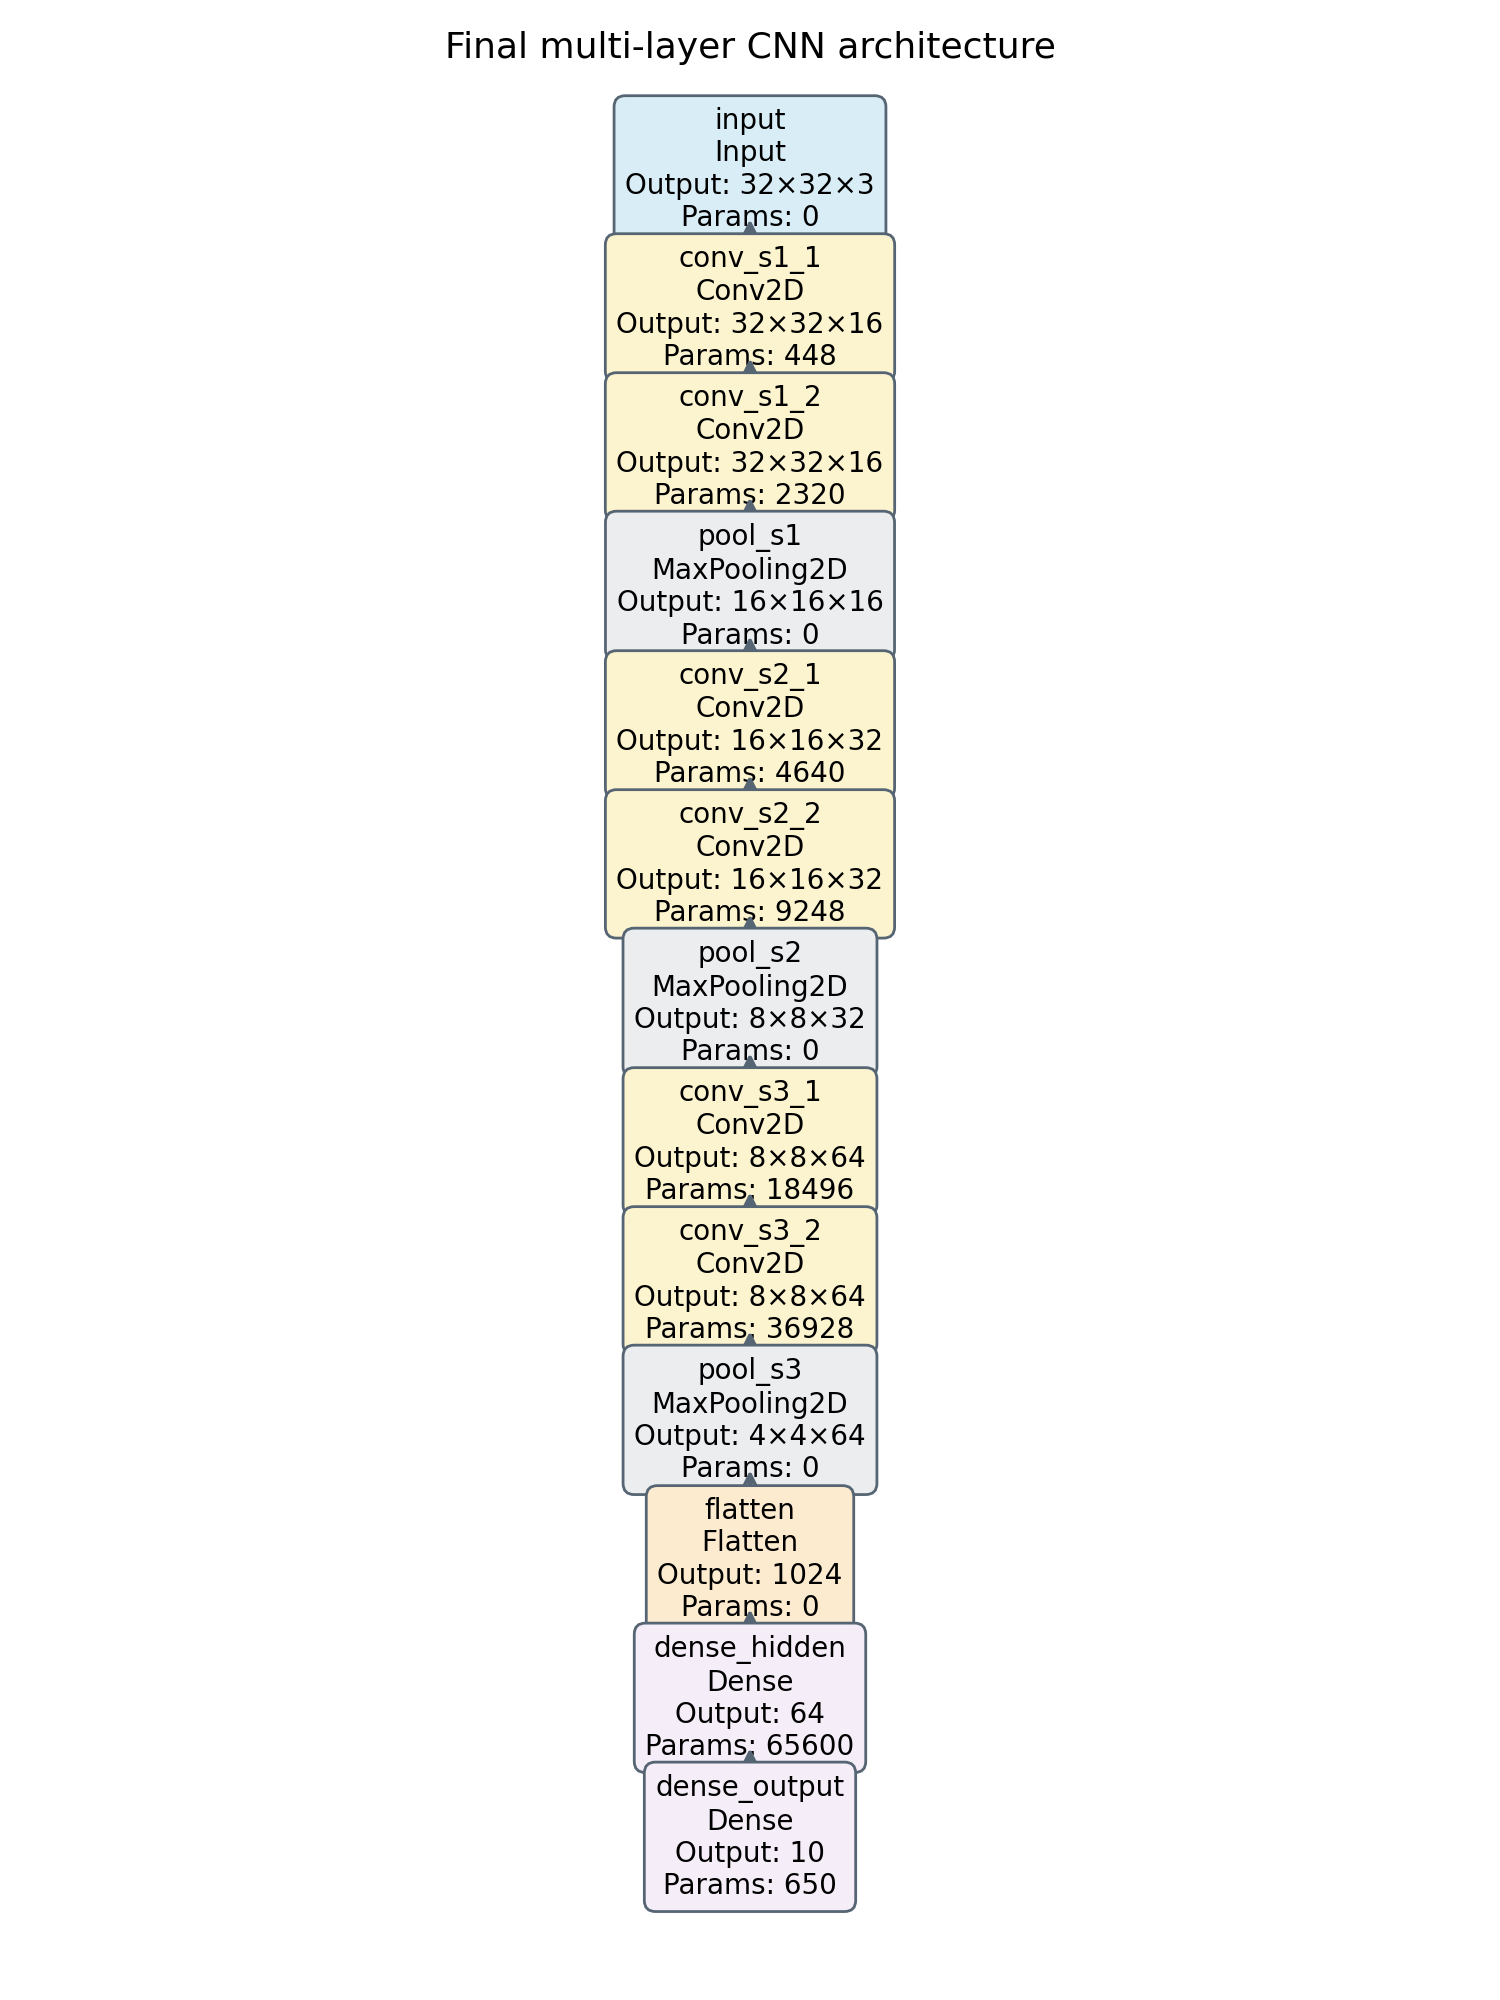

**Courbes d'apprentissage du modèle final**

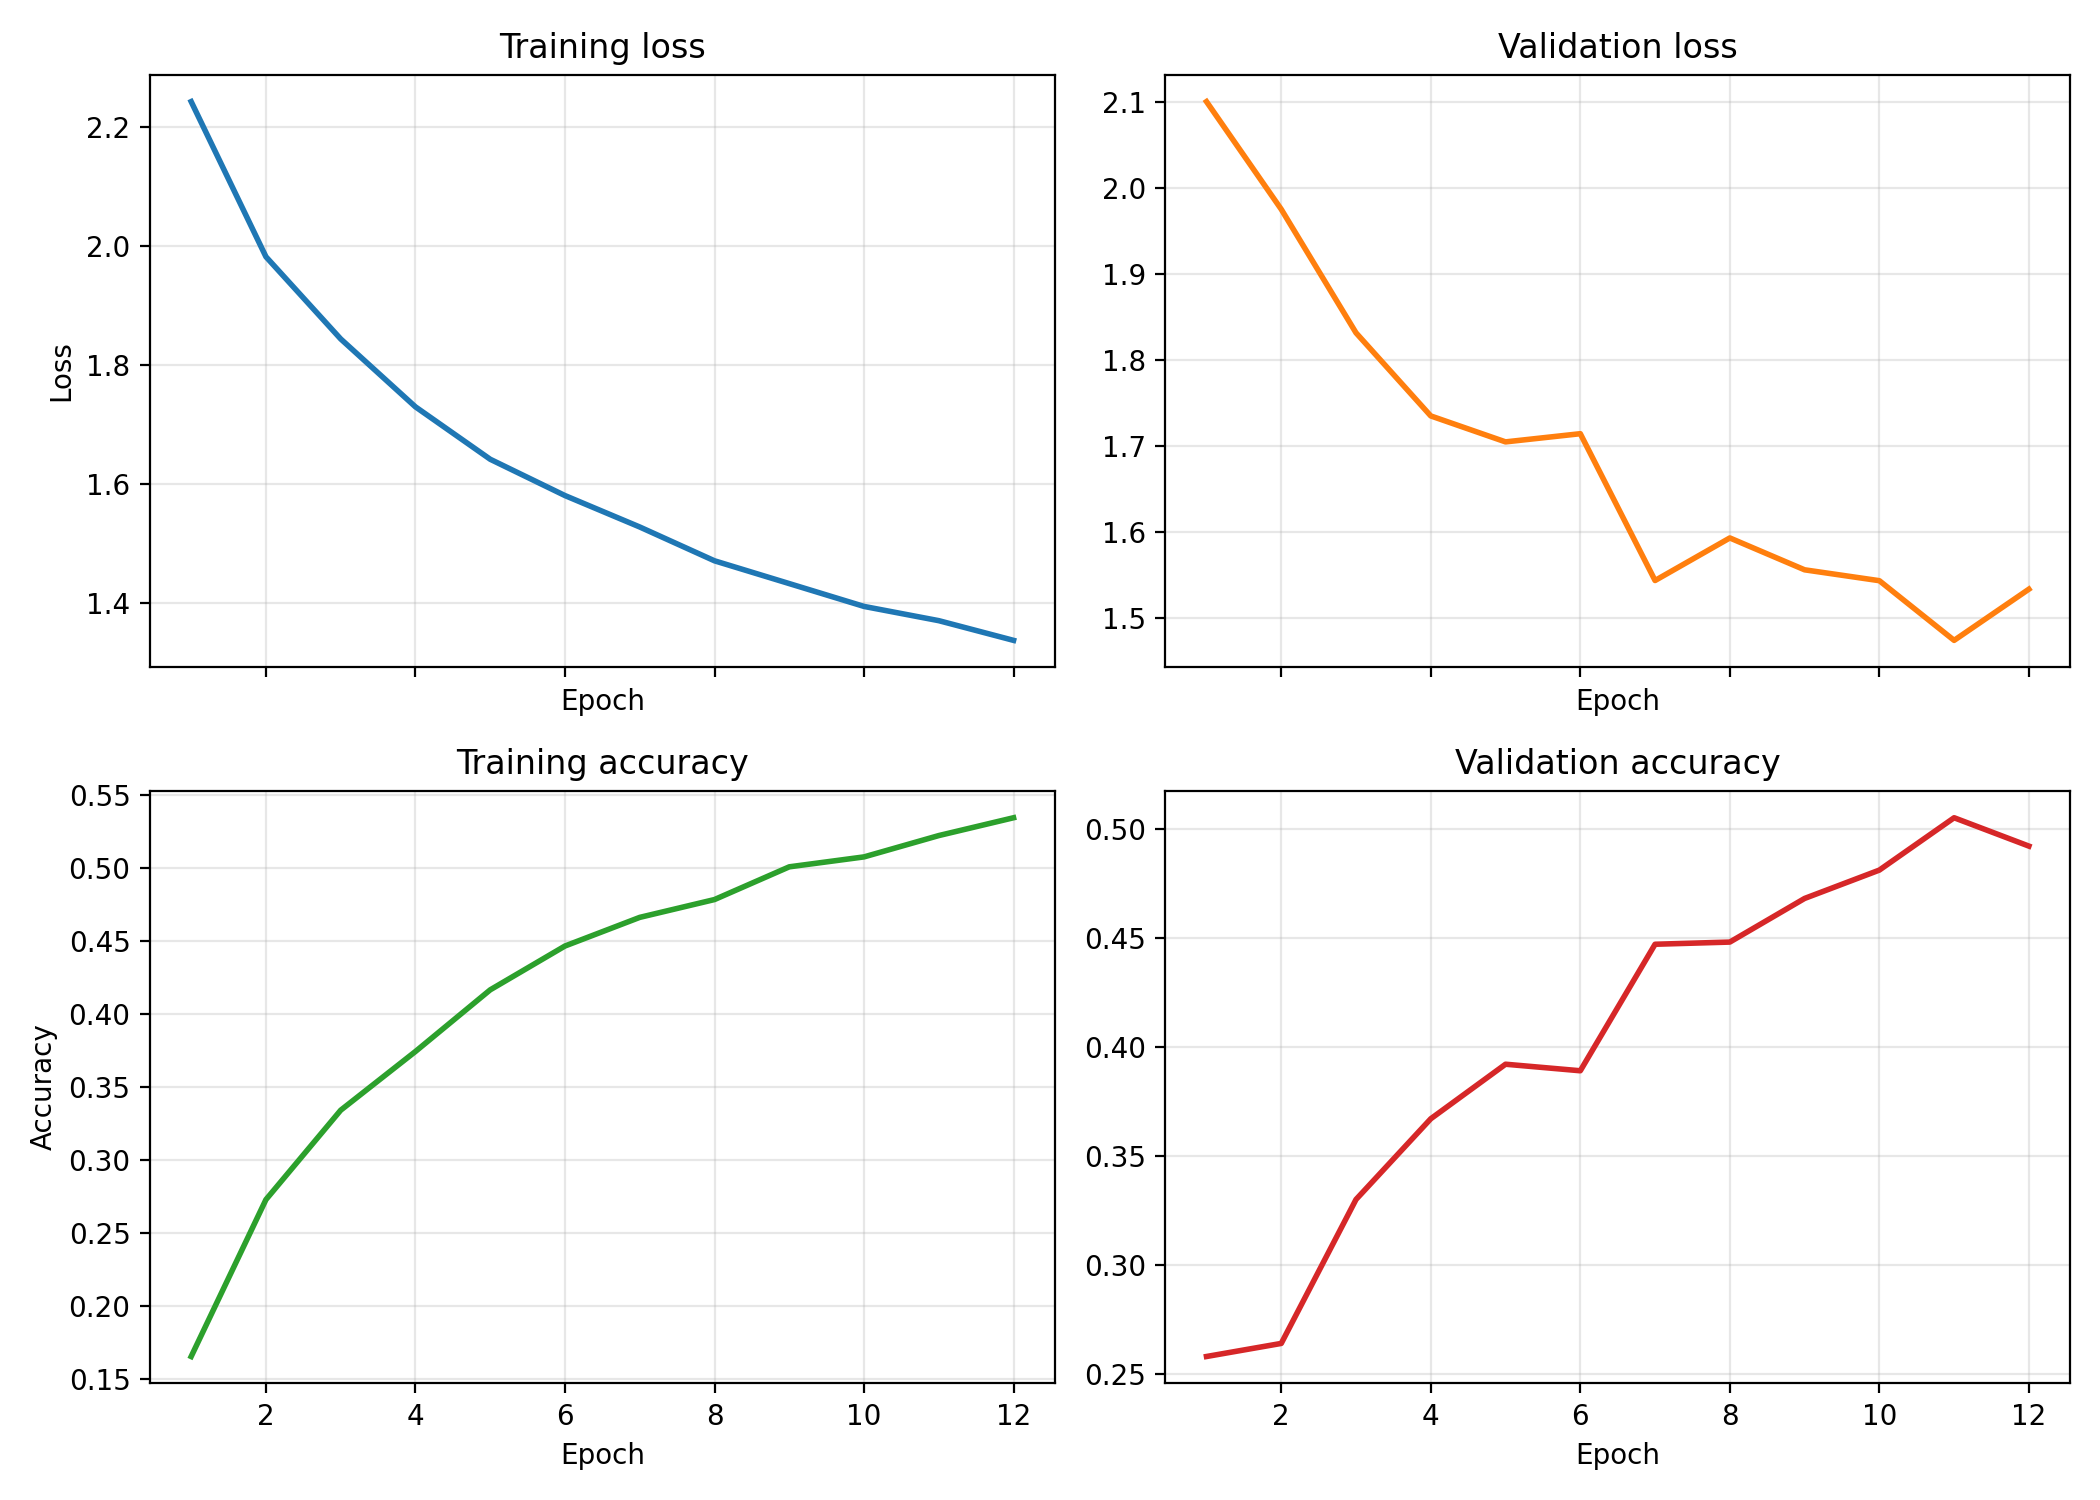

**Matrices de confusion du modèle final**

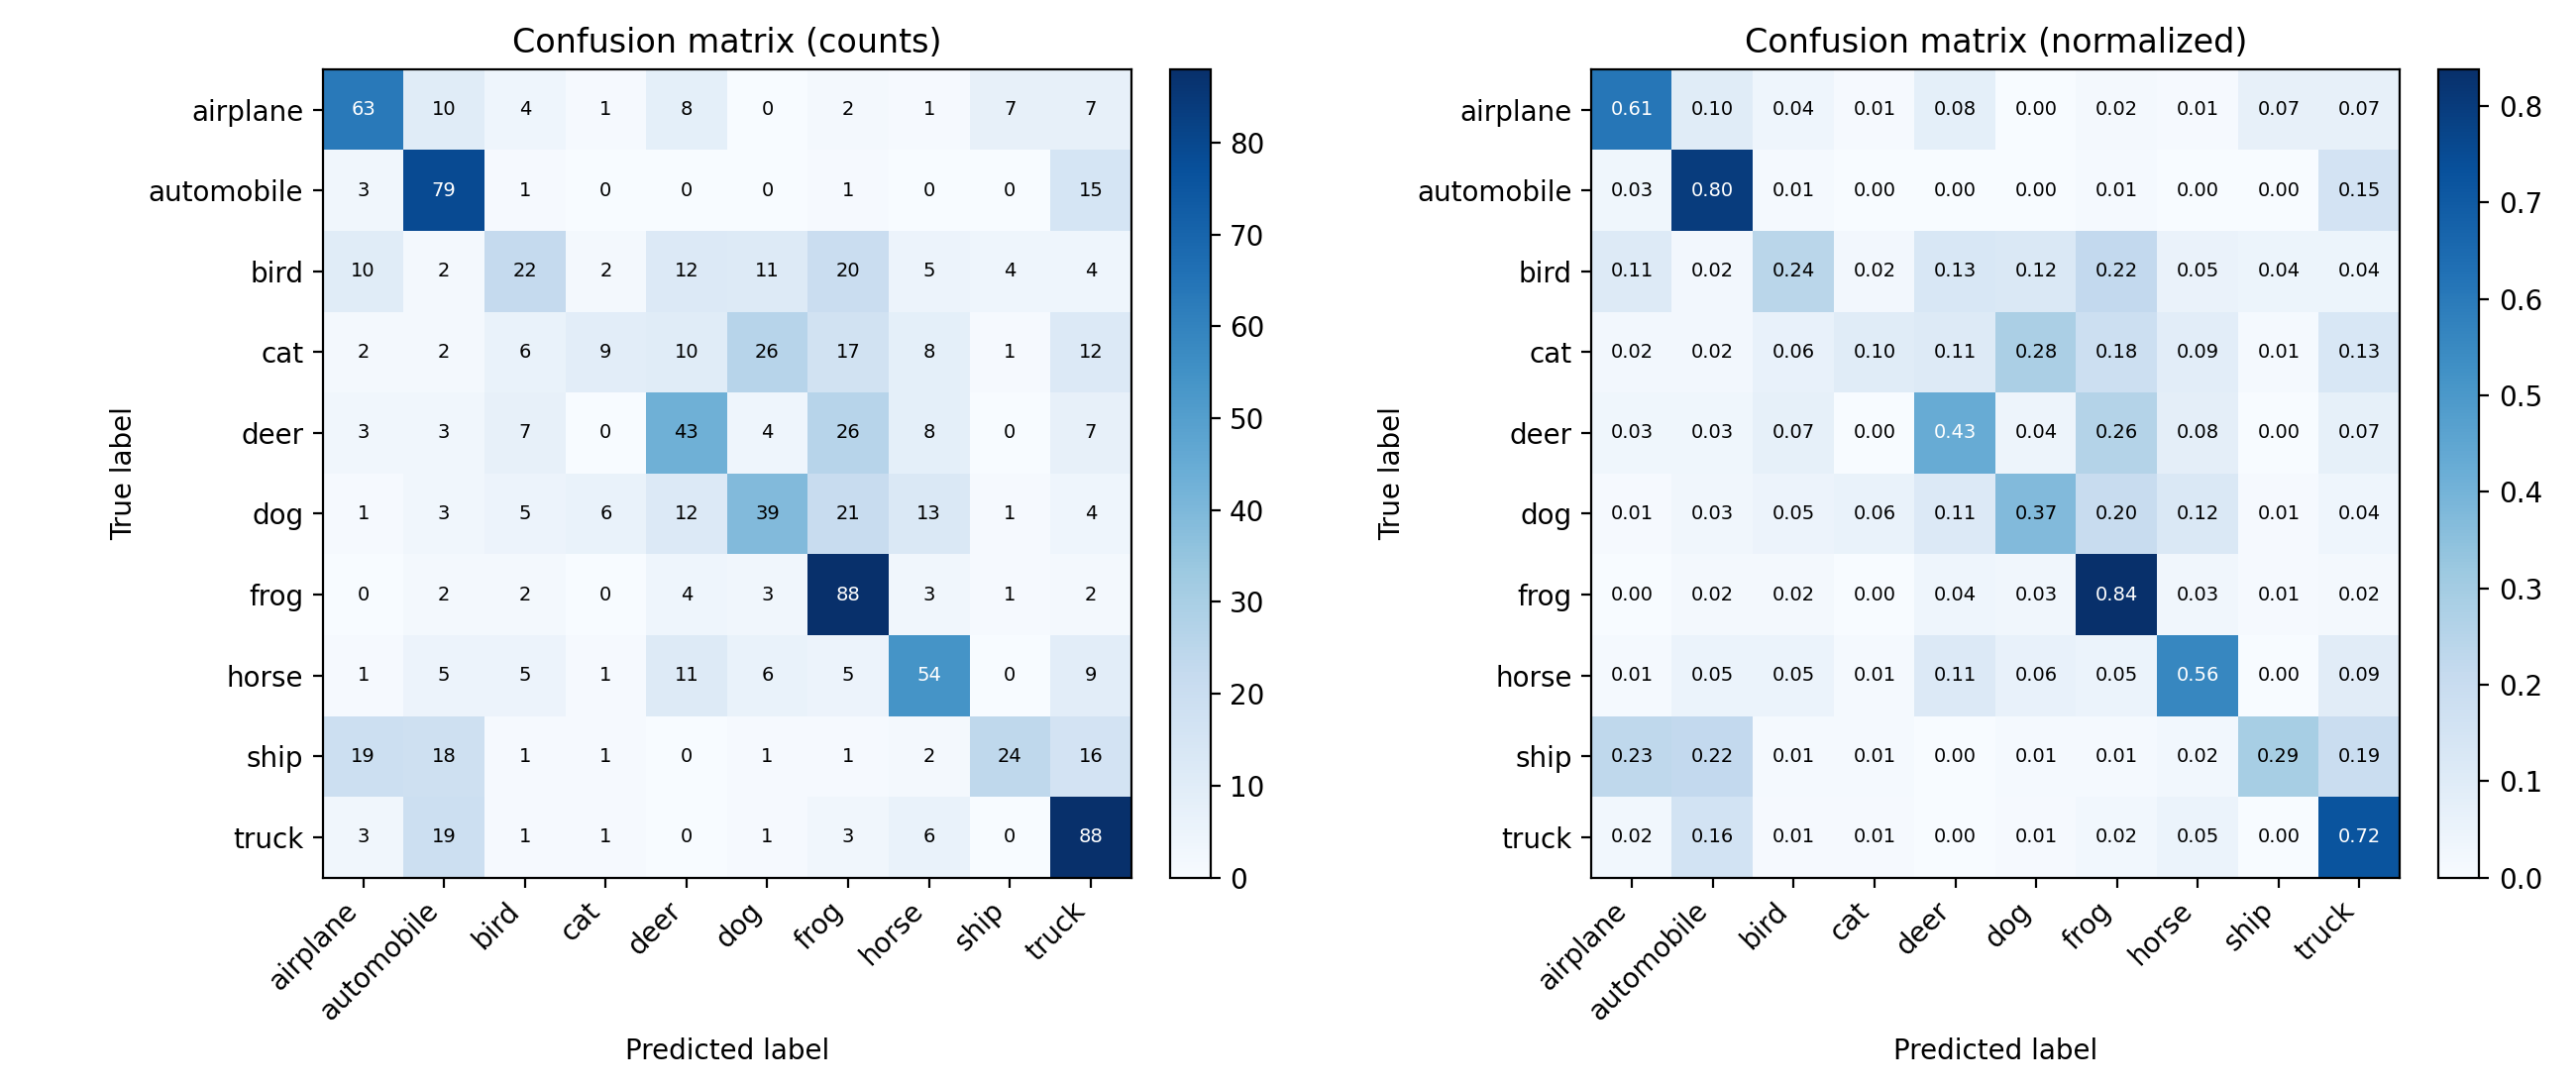

In [43]:
display(Markdown("### VII.8. Figures retenues pour la Section 6"))
image_paths = load_image_paths(figure_dir)
for key, title in [
    ("final_architecture", "Architecture finale multi-couches"),
    ("final_curves", "Courbes d'apprentissage du modèle final"),
    ("final_confusion_matrices", "Matrices de confusion du modèle final"),
]:
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(image_paths[key])))


### VII.9. Observations de synthèse

- Le raffinement par approfondissement convolutionnel améliore nettement la validation par rapport à la baseline à une seule convolution.
- Le modèle profond régularisé retenu fournit le meilleur compromis entre capacité de représentation et maîtrise du sur-apprentissage sur le sous-ensemble CIFAR-10 retenu.
- Le gain de précision s'accompagne d'un coût temporel par epoch plus élevé, ce qui devra être mis en balance dans l'analyse critique du rapport.
- Les matrices de confusion montrent que l'approfondissement ne supprime pas toutes les fragilités de classes, en particulier pour les catégories visuellement proches.


# VIII - Sur-apprentissage pour la Section 7 du rapport

Cette section du notebook prolonge directement la Section 6. Elle réutilise la famille de CNN profonds introduite précédemment, extrait un exemple de sur-apprentissage déjà observé sur `M2`, puis compare plusieurs mécanismes de régularisation sur le même backbone.


In [44]:
from IPython.display import Image, Markdown, display

from scripts.section_7 import (
    BATCH_SIZE,
    DEFAULT_RESULTS_PATH,
    STUDY_EPOCHS,
    STUDY_SEEDS,
    get_audit_summary,
    get_protocol,
    get_variant_configs,
    run_section7_pipeline,
)
from scripts.section_7.visualization import (
    DEFAULT_FIGURE_DIR,
    format_audit_markdown,
    format_example_markdown,
    format_protocol_markdown,
    format_regularization_summary_markdown,
    load_image_paths,
    save_all_section7_figures,
)


In [45]:
section7_intro = {"meta": {"audit": get_audit_summary(), "protocol": get_protocol()}}
display(Markdown(format_audit_markdown(section7_intro)))
display(Markdown("### VIII.2. Protocole retenu"))
display(Markdown(format_protocol_markdown(section7_intro)))
print("Variantes testées :", [variant["name"] for variant in get_variant_configs()])
print("Graines de l'étude :", STUDY_SEEDS)
print("Nombre d'epochs de l'étude :", STUDY_EPOCHS)
print("Batch size fixe :", BATCH_SIZE)
results_path = DEFAULT_RESULTS_PATH
figure_dir = DEFAULT_FIGURE_DIR
force_recompute = False  # True recomputes the full Section 7 study from the notebook.


### VIII.1. Diagnostic

- The Section 6 screening run of M2 already exhibits a clear overfitting pattern on the validation loss curve.
- The regularized M3 model from Section 6 reduces the train/validation gap, but does not fully eliminate the phenomenon.
- Section 7 can therefore remain fully coherent with Section 6 by reusing the M2/M3 family and by comparing dropout and weight decay on the same backbone.

### VIII.2. Protocole retenu

| Parameter | Value |
| --- | --- |
| Dataset | Reduced CIFAR-10 protocol reused from Sections 4 and 6 |
| Subset sizes | 5000 train / 1000 val / 1000 test |
| Preprocessing | Per-image, per-channel standardization |
| Overfitting example | Section 6 screening run of M2 with seed 42 |
| Study seeds | 42, 314 |
| Study epochs | 15 |
| Batch size | 32 |
| Optimizer | Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07) |
| Mechanisms tested | No explicit regularization; Dropout; Weight decay (L2); Dropout + Weight decay (L2) |
| Mechanisms not tested | Data augmentation; Batch normalization; Early stopping as a primary comparison mechanism |

Variantes testées : ['R0', 'R1', 'R2', 'R3']
Graines de l'étude : [42, 314]
Nombre d'epochs de l'étude : 15
Batch size fixe : 32


In [46]:
section7_results = run_section7_pipeline(
    output_path=results_path,
    force_recompute=force_recompute,
    verbose=True,
)
section7_figures = save_all_section7_figures(section7_results, figure_dir=figure_dir)
print(f"Résultats agrégés : {results_path}")
for name, figure_path in section7_figures.items():
    print(f"{name}: {figure_path}")


Résultats agrégés : Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section7\section7_results.json
overfitting_example: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section7_overfitting_example.png
regularization_comparison: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section7_regularization_comparison.png
regularization_summary: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section7_regularization_summary.png


In [47]:
display(Markdown(format_example_markdown(section7_results)))
display(Markdown(format_regularization_summary_markdown(section7_results)))


### VIII.3. Exemple de sur-apprentissage reutilise depuis la Section 6

- Source : `M2`, screening de la Section 6, seed `42`, `10` epochs.
- Minimum de validation loss : `1.6178` a l epoch `4`.
- Validation loss finale : `2.5590`.
- Augmentation apres le minimum : `0.9412`.
- Accuracy train/val finale : `78.96% / 43.60%`.
- Ecart final train-val : `35.36` points.

### VIII.4. Etude comparative des mecanismes de regularisation

| Variant | Mechanism | Final val. acc. (%) | Min val. loss | Overfit increase | Train-val gap (pts) |
| --- | --- | --- | --- | --- | --- |
| R0 | No explicit regularization | 47.30 +/- 2.00 | 1.6192 +/- 0.0014 | 1.3744 +/- 0.0740 | 43.87 +/- 1.37 |
| R1 | Dropout after pooling and before the dense layer | 53.90 +/- 1.80 | 1.2743 +/- 0.0636 | 0.0211 +/- 0.0152 | 5.58 +/- 0.34 |
| R2 | Weight decay only | 48.55 +/- 2.05 | 1.6630 +/- 0.0763 | 1.8604 +/- 0.0397 | 41.79 +/- 0.13 |
| R3 | Combined dropout and weight decay | 55.50 +/- 1.10 | 1.3410 +/- 0.0246 | 0.0000 +/- 0.0000 | 3.70 +/- 0.38 |

### VIII.5. Figures retenues pour la Section 7

**Exemple de sur-apprentissage réutilisé depuis la Section 6**

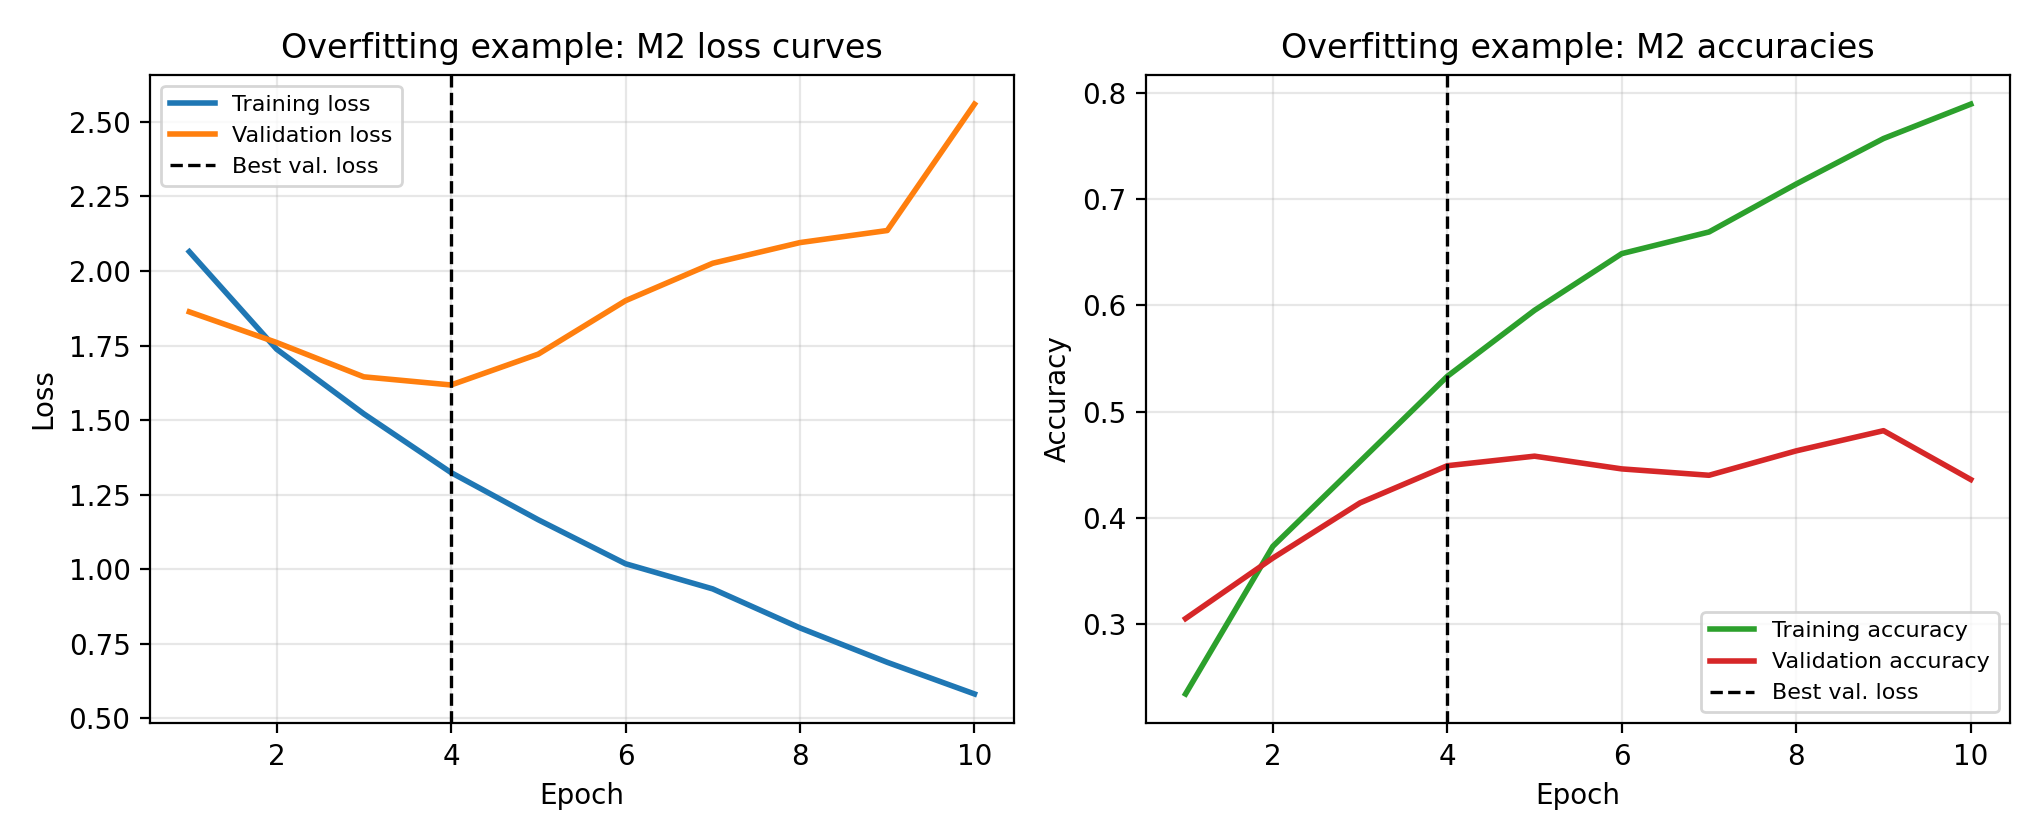

**Comparaison des courbes sous régularisation**

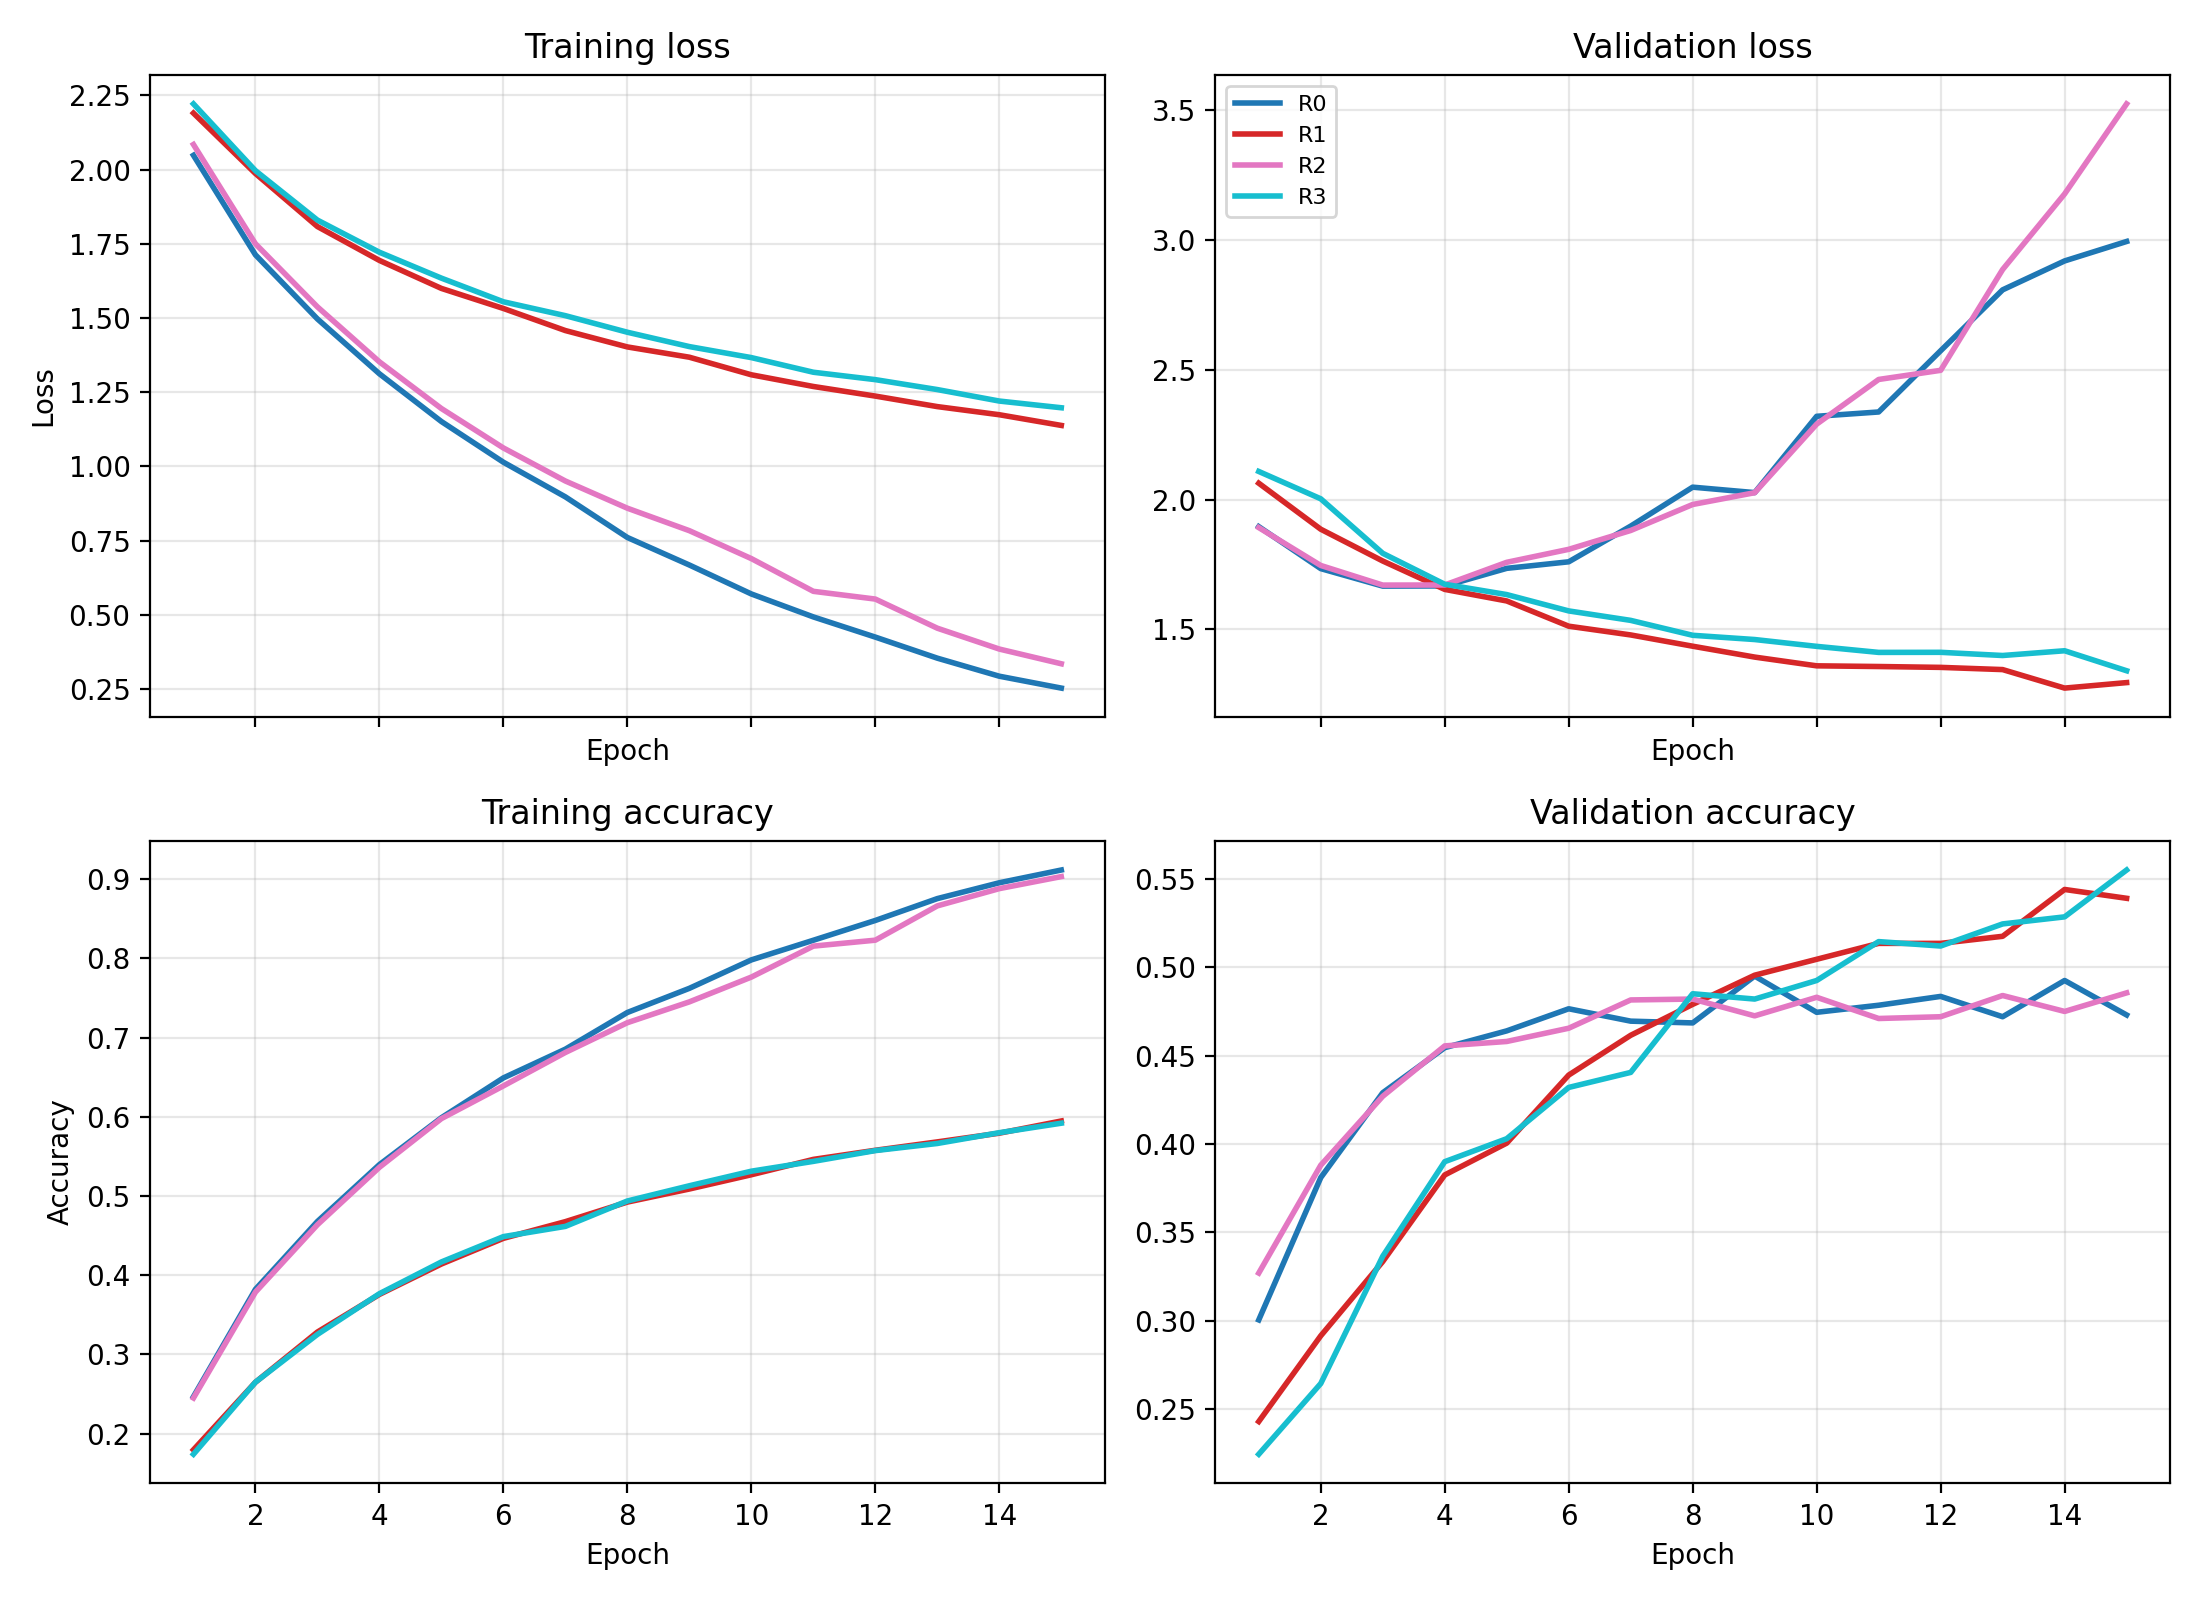

**Synthèse des mécanismes testés**

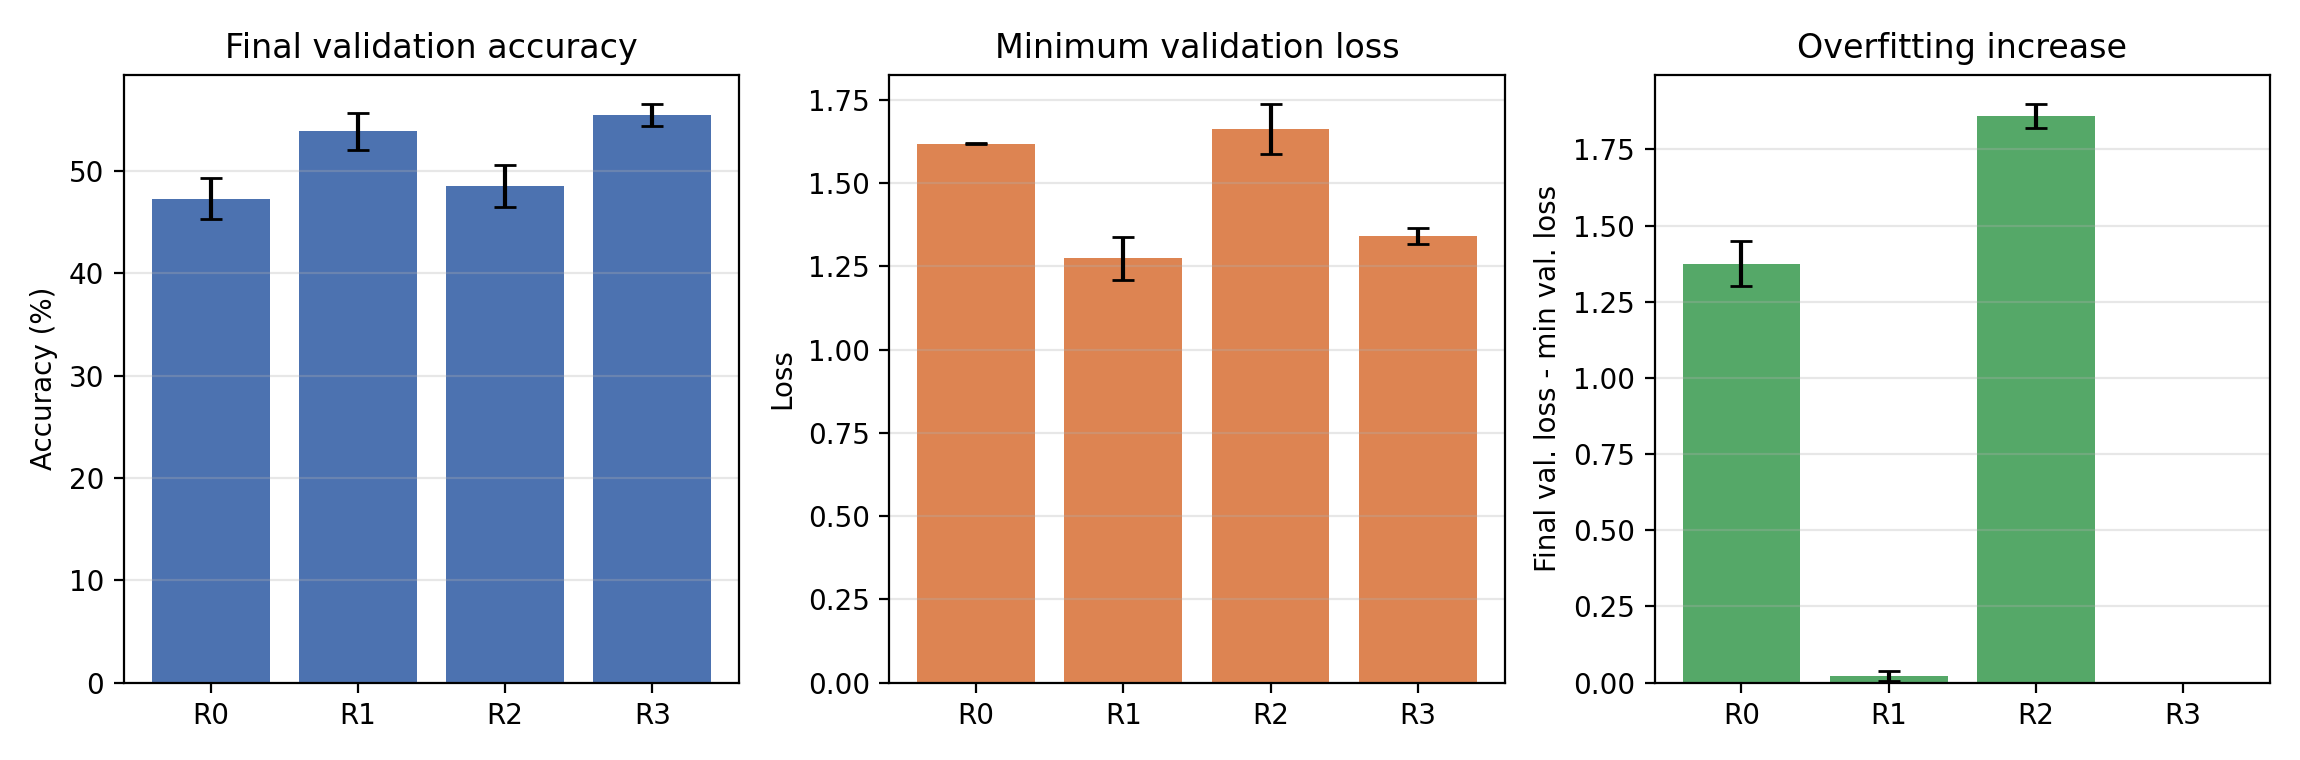

In [48]:
display(Markdown("### VIII.5. Figures retenues pour la Section 7"))
image_paths = load_image_paths(figure_dir)
for key, title in [
    ("overfitting_example", "Exemple de sur-apprentissage réutilisé depuis la Section 6"),
    ("regularization_comparison", "Comparaison des courbes sous régularisation"),
    ("regularization_summary", "Synthèse des mécanismes testés"),
]:
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(image_paths[key])))


### VIII.6. Observations de synthèse

- Le screening de `M2` déjà présent dans la Section 6 fournit un exemple net de sur-apprentissage : la `val_loss` remonte après son minimum alors que la `training loss` continue de diminuer.
- La Section 7 compare ensuite des mécanismes de régularisation sur le même backbone profond afin de distinguer réduction du sur-apprentissage et ralentissement de l'optimisation.
- Le couple `dropout + L2` est attendu comme le mécanisme le plus cohérent avec la version régularisée `M3` retenue en Section 6.
